# SIG742 2026T2 Assignment 2 Starter Notebook: Group Forecasting Project

<div style="border: 3px solid #1d4ed8; padding: 0.9rem 1rem; border-radius: 6px; background: #000;">
<strong>Forecasting Performance Determines Your Final Grade Band</strong>
<p>Your Forecasting Performance Grade determines the grade band for your final A2 mark.</p>
<ul>
<li><strong>Forecasting measures:</strong> The grade is determined primarily by MASE. MAPE is used as supporting cross-check evidence.</li>
<li><strong>Questions Q1-Q7:</strong> Your marks for these questions determine the exact final mark within the grade band.</li>
<li><strong>Grade bands:</strong> HD: 80-100; D: 70-79; C: 60-69; P: 50-59; F: 0-49.</li>
</ul>
<p>For example, if your Forecasting Performance Grade is D, your final A2 mark will be between 70 and 79, with the exact mark determined by your marks for Questions Q1-Q7.</p>
</div>

Complete this notebook for Assignment 2. Preserve the required headings, function names, object names, and written-answer markers.

<div style="border: 2px solid #b91c1c; padding: 0.9rem 1rem; border-radius: 6px; background: #000;">
<strong>Required autograding markers</strong>
<p>Do not delete, rename, edit, move, or reorder any <code>A2:ANSWER</code> START/END marker comment. Write each response between the matching markers for that question. Changed or missing markers may prevent a response from being detected correctly during marking.</p>
</div>


## Group Details

Complete the group details before submission. Follow the Olympus Assignment requirements for peer/self-review and contribution material.

`email_username` is the part before `@deakin.edu.au`; for example, use `xyz` for `xyz@deakin.edu.au`. If your group has more or fewer than three members because of an approved arrangement, adjust the `members` list and explain this in the contribution/video evidence.


In [38]:
GROUP_INFO = {
    "group_id": "T34",
    "group_name": "T34",
    "members": [
        {
            "student_id": "226486763",
            "name": "Wassim Ibrahim",
            "deakin_email": "s226486763@deakin.edu.au",
            "email_username": "s226486763",
            "role_or_contribution": "Group Member, Orchestrator and Data Scientist",
        },
        {
            "student_id": "",
            "name": "",
            "deakin_email": "",
            "email_username": "",
            "role_or_contribution": "Group Member and Data Scientist",
        },
        {
            "student_id": "",
            "name": "",
            "deakin_email": "",
            "email_username": "",
            "role_or_contribution": "Group Member and Data Scientist",
        },
    ],
    "unit": "SIG742",
    "assignment": "A2",
    "teaching_period": "2026T2",
}


In [39]:
A2_REQUIRED_OBJECTS = [
    "GROUP_INFO",
    "raw_tourism_data",
    "training_actual_wide_to_2023M02",
    "validation_actual_wide_2023M03_2023M07",
    "public_history_wide_to_2023M07",
    "baseline_lag1_validation_forecast_wide",
    "baseline_lag12_validation_forecast_wide",
    "baseline_lag1_validation_audit",
    "baseline_lag12_validation_audit",
    "baseline_validation_comparison",
    "baseline_validation_summary",
    "tourism_series_long",
    "modelling_data_or_feature_table",
    "external_feature_log",
    "validation_forecasts",
    "validation_metrics",
    "model_summary",
    "forecast_submission_wide",
    "forecast_submission_audit",
]

A2_REQUIRED_FUNCTIONS = [
    "generate_naive_forecast_wide",
    "validate_forecast_actual_wide",
    "evaluate_forecast_wide",
]


## Required scaffold names and forecasting pipeline

Do not delete or rename required functions, objects, question headings, or written-answer markers. You may add helper cells, functions, models, packages, and intermediate variables.

Key required objects:

| Name | Meaning |
| --- | --- |
| `GROUP_INFO` | Group/member metadata, including Deakin email and email username. |
| `raw_tourism_data` | Public `ISF-TDF2023` dataset loaded into Python. |
| `training_actual_wide_to_2023M02` | Training actuals up to validation cutoff `2023M02`. |
| `validation_actual_wide_2023M03_2023M07` | Visible validation actual/result table. |
| `public_history_wide_to_2023M07` | Public history available at final cutoff `2023M07`. |
| `baseline_validation_comparison` | Destination-level MAE, MASE, MAPE, denominator diagnostics, and row counts for both required baselines. |
| `baseline_validation_summary` | Aggregate validation measures for both required baselines. |
| `tourism_series_long` | Long-format DataFrame with at least `Date`, `destination`, and `demand`. |
| `modelling_data_or_feature_table` | Cutoff-safe modelling data, feature table, or concise model-ready evidence summary. |
| `external_feature_log` | Fixed-column external-source DataFrame, or a zero-row DataFrame with those columns if no external data is used. |
| `validation_forecasts` | Long-format validation forecast DataFrame using `VALIDATION_FORECAST_COLUMNS`. |
| `validation_metrics` | Destination-level validation measure DataFrame using `VALIDATION_METRIC_COLUMNS`. |
| `model_summary` | One-row-per-model DataFrame using `MODEL_SUMMARY_COLUMNS`. |
| `forecast_submission_wide` | Final 12-row all-20 destination forecast table exported directly to CSV. |
| `forecast_submission_audit` | Fixed-key Q2 forecast-only audit for the final wide forecast table. |

Pipeline: Q1 creates naive wide baselines; Q2 audits schema/alignment; Q3 calculates measures; integrated Part I evidence creates baseline tables; Q4 develops models; Q5 exports final forecasts; Q6 interprets performance and markets; Q7 demonstrates reproducibility and collaboration.

## Assignment overview

Build a reproducible forecasting workflow for the public TULIP Lab `ISF-TDF2023` tourism demand dataset. Forecast all 20 destination series for `2023M08` to `2024M07`, analyse selected markets, and submit a wide-format forecast CSV with one row per forecast month.

Assessment structure: Part I functions 15 marks, Part II forecasting project 70 marks, compulsory group video 15 marks. Any forecasting method is allowed if it is cutoff-safe, reproducible, stable enough for assessment, and interpretable.

<div style="border: 2px solid #475569; padding: 0.9rem 1rem; border-radius: 6px; background: #000;">
<strong>Reproducibility and Stability</strong>
<p>The notebook should rerun from a clean runtime, preserve required names, document inputs and seeds where relevant, regenerate the final CSV from `forecast_submission_wide`, and avoid local absolute paths, manual CSV edits, placeholder forecasts, or uncontrolled stochastic outputs.</p>
</div>

Final output: `forecast_submission_wide` with one `Date` column, exactly 12 rows for `2023M08` to `2024M07`, and exactly the 20 public-dataset destination columns. Export the final CSV directly from this object with `index=False`.

Performance measures: MASE and MAPE are both required. MAE is used where needed to support MASE numerator checking. See the [A2 Forecast Measures Guide](SIG742-2026T2-A2-Forecast-Measures-Guide.md) for definitions and worked examples. See the [A2 Function Examples Guide](SIG742-2026T2-A2-Function-Examples.md) for detailed Q1-Q3 toy inputs, expected outputs, and function I/O examples.


## Setup and dataset loading

This section provides a Google Colab / online execution option using a public raw URL. You may add a local execution option if your group uses a cloned repository, but do not rely on absolute local paths.


#### We will start with this pre-defined code in this notebook to load the data, keep the pre-defined objects for later use, and inspect the dataset

### Step 1 - Data Loading, Ingestion & Parameters Definitions

In [40]:
import matplotlib.pyplot as plt
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)


In [41]:
DATA_URL = "https://raw.githubusercontent.com/tulip-lab/open-data/main/ISF-TDF2023/ISF-TDF2023.csv"

TRAIN_END = "2023M02"
VALIDATION_MONTHS = [f"2023M{month:02d}" for month in range(3, 8)]
VALIDATION_START = VALIDATION_MONTHS[0]
VALIDATION_END = VALIDATION_MONTHS[-1]
FORECAST_MONTHS = [f"2023M{month:02d}" for month in range(8, 13)] + [f"2024M{month:02d}" for month in range(1, 8)]
FORECAST_START = FORECAST_MONTHS[0]
FORECAST_END = FORECAST_MONTHS[-1]
FINAL_FORECAST_MONTHS = FORECAST_MONTHS

FOCUS_REQUIRED_DESTINATIONS = ["Australia", "Japan"]
FINAL_FORECAST_DATE_COLUMN = "Date"

Q2_AUDIT_FIELDS = [
    "is_valid",
    "can_align",
    "forecast_row_count",
    "actual_row_count",
    "expected_row_count",
    "missing_months_in_forecast",
    "missing_months_in_actual",
    "extra_months_in_forecast",
    "extra_months_in_actual_source",
    "missing_destinations_in_forecast",
    "missing_destinations_in_actual",
    "extra_columns_in_forecast",
    "duplicate_forecast_dates",
    "duplicate_actual_dates",
    "missing_forecast_value_count",
    "missing_actual_value_count",
    "nonnumeric_forecast_value_count",
    "nonnumeric_actual_value_count",
    "nonfinite_forecast_value_count",
    "nonfinite_actual_value_count",
]

DESTINATION_METRIC_COLUMNS = [
    "destination",
    "n",
    "mae",
    "mase",
    "mape",
    "denominator",
    "n_denominator_pairs",
    "mase_available",
    "denominator_warning",
]
AGGREGATE_METRIC_FIELDS = [
    "n_destinations",
    "mean_mase",
    "median_mase",
    "mean_mape",
]

EXTERNAL_FEATURE_LOG_COLUMNS = [
    "source_name",
    "source_url_or_reference",
    "local_file_or_url",
    "retrieval_date",
    "publication_or_release_date",
    "latest_observation_used",
    "cutoff_applicable",
    "features_created",
    "transformation_summary",
    "licence_or_access_notes",
]
VALIDATION_FORECAST_COLUMNS = [
    "model_label",
    "Date",
    "destination",
    "forecast",
]
VALIDATION_METRIC_COLUMNS = ["model_label"] + DESTINATION_METRIC_COLUMNS
MODEL_SUMMARY_COLUMNS = [
    "model_label",
    "model_family",
    "n_destinations",
    "mean_mase",
    "median_mase",
    "mean_mape",
    "selected",
    "selection_rationale",
    "reproducibility_notes",
    "stability_notes",
]

BASELINE_COMPARISON_COLUMNS = [
    "model_label",
    "lag",
] + DESTINATION_METRIC_COLUMNS
BASELINE_SUMMARY_COLUMNS = [
    "model_label",
    "lag",
] + AGGREGATE_METRIC_FIELDS

In [42]:
# Option A: Google Colab / online execution.
raw_tourism_data = pd.read_csv(DATA_URL)

# Option B: local execution, if you have deliberately saved a local copy.
# local_path = Path("data") / "ISF-TDF2023.csv"
# raw_tourism_data = pd.read_csv(local_path)

DESTINATION_COLUMNS = [column for column in raw_tourism_data.columns if column != FINAL_FORECAST_DATE_COLUMN]
FINAL_FORECAST_COLUMNS = [FINAL_FORECAST_DATE_COLUMN] + DESTINATION_COLUMNS
REQUIRED_DESTINATIONS = DESTINATION_COLUMNS

# Inspect the first few rows during your own work.
# raw_tourism_data.head()


-----------------------

### Step 2 - Initial Inspecion by our Team

In [43]:
raw_tourism_data.head()

,Date,Canada,Chile,Mexico,Taiwan China,Hong Kong China,Japan,South Korea,Macao China,Maldives,Cambodia,Indonesia,Singapore,New Zealand,USA,Thailand,Turkey,Australia,Hawaii,Austria,Czech
0,1989M01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1660.0,532.0,NaN,NaN
1,1989M02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3090.0,1550.0,NaN,NaN
2,1989M03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2570.0,822.0,NaN,NaN
3,1989M04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1580.0,1010.0,NaN,NaN
4,1989M05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1850.0,1383.0,NaN,NaN


In [44]:
raw_tourism_data[["Date", "Australia", "Hawaii"]].head()

,Date,Australia,Hawaii
0,1989M01,1660.0,532.0
1,1989M02,3090.0,1550.0
2,1989M03,2570.0,822.0
3,1989M04,1580.0,1010.0
4,1989M05,1850.0,1383.0


In [45]:
print("Shape:", raw_tourism_data.shape)
print("Number of destinations:", len(DESTINATION_COLUMNS))
print("Date range:", raw_tourism_data["Date"].iloc[0], "to", raw_tourism_data["Date"].iloc[-1])

Shape: (427, 21)
Number of destinations: 20
Date range: 1989M01 to 2024M07


In [46]:
raw_tourism_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 427 entries, 0 to 426
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             427 non-null    object 
 1   Canada           259 non-null    float64
 2   Chile            124 non-null    float64
 3   Mexico           223 non-null    float64
 4   Taiwan China     181 non-null    float64
 5   Hong Kong China  295 non-null    float64
 6   Japan            319 non-null    float64
 7   South Korea      307 non-null    float64
 8   Macao China      295 non-null    float64
 9   Maldives         304 non-null    float64
 10  Cambodia         247 non-null    float64
 11  Indonesia        127 non-null    float64
 12  Singapore        259 non-null    float64
 13  New Zealand      259 non-null    float64
 14  USA              283 non-null    float64
 15  Thailand         337 non-null    float64
 16  Turkey           331 non-null    float64
 17  Australia       

In [47]:
raw_tourism_data.isna().sum()

Date                 0
Canada             168
Chile              303
Mexico             204
Taiwan China       246
Hong Kong China    132
Japan              108
South Korea        120
Macao China        132
Maldives           123
Cambodia           180
Indonesia          300
Singapore          168
New Zealand        168
USA                144
Thailand            90
Turkey              96
Australia           12
Hawaii              12
Austria            184
Czech              288
dtype: int64

In [48]:
# Checking for duplicate dates
print("Duplicate dates:", raw_tourism_data["Date"].duplicated().sum())

Duplicate dates: 0


In [49]:
# Checking the first available month for each destination
first_valid_dates = {}

for column in DESTINATION_COLUMNS:
    first_index = raw_tourism_data[column].first_valid_index()
    first_valid_dates[column] = raw_tourism_data.loc[first_index, "Date"]

pd.Series(first_valid_dates, name="first_valid_date")

Canada             2002M01
Chile              2012M01
Mexico             2005M01
Taiwan China       2008M07
Hong Kong China    1999M01
Japan              1997M01
South Korea        1998M01
Macao China        1999M01
Maldives           1998M01
Cambodia           2003M01
Indonesia          2013M01
Singapore          2002M01
New Zealand        2002M01
USA                2000M01
Thailand           1995M01
Turkey             1996M01
Australia          1989M01
Hawaii             1989M01
Austria            2003M05
Czech              2012M01
Name: first_valid_date, dtype: object

The destination series also have different historical starting points. Australia and Hawaii begin in `1989M01`, while some destinations, such as Indonesia, only begin in `2013M01`. This explains many of the missing values observed at the beginning of the dataset and means that the available training history varies by destination.

In [50]:
# Checking for missing gaps within each destination history
cutoff_index = raw_tourism_data.index[raw_tourism_data["Date"] == "2023M07"][0]

internal_missing = {}

for column in DESTINATION_COLUMNS:
    first_index = raw_tourism_data[column].first_valid_index()
    internal_missing[column] = raw_tourism_data.loc[
        first_index:cutoff_index, column
    ].isna().sum()

pd.Series(internal_missing, name="internal_missing")

Canada              0
Chile              15
Mexico              0
Taiwan China        0
Hong Kong China     0
Japan               0
South Korea         0
Macao China         0
Maldives            3
Cambodia            0
Indonesia           0
Singapore           0
New Zealand         0
USA                 0
Thailand            6
Turkey              0
Australia           0
Hawaii              0
Austria             0
Czech               0
Name: internal_missing, dtype: int64

In [51]:
# Checking the missing months within each destination history
for column in DESTINATION_COLUMNS:
    first_index = raw_tourism_data[column].first_valid_index()

    missing_dates = raw_tourism_data.loc[
        first_index:cutoff_index
    ].loc[
        raw_tourism_data.loc[first_index:cutoff_index, column].isna(),
        "Date"
    ].tolist()

    if missing_dates:
        print(f"{column}: {missing_dates}")

Chile: ['2017M11', '2017M12', '2020M04', '2020M05', '2020M06', '2020M07', '2020M08', '2020M09', '2020M10', '2021M04', '2021M05', '2021M06', '2021M07', '2021M08', '2021M09']
Maldives: ['2020M04', '2020M05', '2020M06']
Thailand: ['2020M04', '2020M05', '2020M06', '2020M07', '2020M08', '2020M09']


In [52]:
# Checking completeness of the validation period
validation_check = raw_tourism_data[
    raw_tourism_data["Date"].isin(VALIDATION_MONTHS)
]

print("Validation shape:", validation_check.shape)
print("Missing values:", validation_check[DESTINATION_COLUMNS].isna().sum().sum())

Validation shape: (5, 21)
Missing values: 0


#### Step 2 – Summary & Initial Findings

The tourism dataset was successfully loaded with **427 monthly observations** from `1989M01` to `2024M07`, covering **20 destination series** plus the `Date` column. All destination variables are numeric (`float64`), while `Date` is currently stored as an object.

The destination series have different historical starting points, which explains most of the missing values in the earlier years. Australia and Hawaii have the longest histories, beginning in `1989M01`, while some destinations begin considerably later.

After checking for gaps within each available destination history up to the final forecasting cutoff (`2023M07`), internal missing values were identified only for:
- Chile: 15 months
- Maldives: 3 months
- Thailand: 6 months

No duplicate dates were found.

The required validation period (`2023M03` to `2023M07`) contains all **5 months** and has **no missing destination values**.

Although the raw dataset extends to `2024M07`, data after `2023M07` must not be used when developing the final forecasts. The period `2023M08` to `2024M07` is treated as the final forecast horizon.

----------------

### Step 3 - Validation and Final-Cutoff Split Objects

### Validation and final-cutoff split objects

Create these required scaffold objects from `raw_tourism_data` using the `Date` column and the existing constants. Use a real year-month representation such as `pandas.Period(..., freq="M")`; do not filter by direct string comparison on month labels.

- `training_actual_wide_to_2023M02`: used for validation MASE denominators, validation MAPE alignment, and validation baseline generation cutoff.
- `validation_actual_wide_2023M03_2023M07`: visible validation actual/result table used for Q1-Q3 integrated evidence and Q4 validation comparison.
- `public_history_wide_to_2023M07`: public history available for the final forecasting cutoff and final MASE denominator concept; no final-evaluation actual/result values are included.


In [53]:
training_actual_wide_to_2023M02 = None  # TODO: subset raw_tourism_data to months up to TRAIN_END.
validation_actual_wide_2023M03_2023M07 = None  # TODO: subset raw_tourism_data to VALIDATION_MONTHS.
public_history_wide_to_2023M07 = None  # TODO: subset raw_tourism_data to months up to 2023M07.

# Period-based split pattern after you confirm the Date labels and columns.
# Do not use direct string comparison for month filtering.
# def month_label_to_period(month_label):
#     return pd.Period(str(month_label).replace("M", "-"), freq="M")
#
# raw_tourism_data_with_period = raw_tourism_data.copy()
# raw_tourism_data_with_period["_month_period"] = raw_tourism_data_with_period[
#     FINAL_FORECAST_DATE_COLUMN
# ].map(month_label_to_period)
#
# training_actual_wide_to_2023M02 = raw_tourism_data_with_period.loc[
#     raw_tourism_data_with_period["_month_period"] <= month_label_to_period(TRAIN_END),
#     FINAL_FORECAST_COLUMNS,
# ].copy()
# validation_periods = [month_label_to_period(month) for month in VALIDATION_MONTHS]
# validation_actual_wide_2023M03_2023M07 = raw_tourism_data_with_period.loc[
#     raw_tourism_data_with_period["_month_period"].isin(validation_periods),
#     FINAL_FORECAST_COLUMNS,
# ].copy()
# public_history_wide_to_2023M07 = raw_tourism_data_with_period.loc[
#     raw_tourism_data_with_period["_month_period"] <= month_label_to_period("2023M07"),
#     FINAL_FORECAST_COLUMNS,
# ].copy()
#
# The helper column _month_period is not part of the required wide tables.


### Step 3.1

In [54]:
# Converting the month labels to a proper monthly period
def month_label_to_period(month_label):
    return pd.Period(str(month_label).replace("M", "-"), freq="M")


# Creating a working copy with a month-aware helper column
raw_tourism_data_with_period = raw_tourism_data.copy()

raw_tourism_data_with_period["_month_period"] = (
    raw_tourism_data_with_period[FINAL_FORECAST_DATE_COLUMN]
    .map(month_label_to_period)
)

raw_tourism_data_with_period.head()

,Date,Canada,Chile,Mexico,Taiwan China,Hong Kong China,Japan,South Korea,Macao China,Maldives,Cambodia,Indonesia,Singapore,New Zealand,USA,Thailand,Turkey,Australia,Hawaii,Austria,Czech,_month_period
0,1989M01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1660.0,532.0,NaN,NaN,1989-01
1,1989M02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3090.0,1550.0,NaN,NaN,1989-02
2,1989M03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2570.0,822.0,NaN,NaN,1989-03
3,1989M04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1580.0,1010.0,NaN,NaN,1989-04
4,1989M05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1850.0,1383.0,NaN,NaN,1989-05


### Step 3.2

In [55]:
# Creating the training data up to the validation cutoff
training_actual_wide_to_2023M02 = raw_tourism_data_with_period.loc[
    raw_tourism_data_with_period["_month_period"]
    <= month_label_to_period(TRAIN_END),
    FINAL_FORECAST_COLUMNS,
].copy()

training_actual_wide_to_2023M02.tail()

,Date,Canada,Chile,Mexico,Taiwan China,Hong Kong China,Japan,South Korea,Macao China,Maldives,Cambodia,Indonesia,Singapore,New Zealand,USA,Thailand,Turkey,Australia,Hawaii,Austria,Czech
405,2022M10,8817.0,822.0,6888.0,2461.0,47607.0,21498.0,22940.0,518843.0,1157.0,13490.0,17166.0,14971.0,2327.0,32137.0,35410.0,8558.0,7070.0,434.0,5018.0,7180.0
406,2022M11,7216.0,1023.0,10359.0,3645.0,58694.0,21016.0,24174.0,320267.0,1175.0,14733.0,20065.0,16024.0,2866.0,31651.0,37113.0,7717.0,9100.0,795.0,4220.0,8048.0
407,2022M12,9217.0,1372.0,17627.0,5437.0,67244.0,33567.0,27367.0,336593.0,2468.0,16227.0,29642.0,19684.0,4731.0,48435.0,54146.0,10954.0,13880.0,2068.0,7166.0,9546.0
408,2023M01,9244.0,872.0,10303.0,9633.0,280525.0,31200.0,24946.0,991641.0,5796.0,24978.0,27080.0,28363.0,4949.0,63386.0,91841.0,8899.0,14630.0,1164.0,4440.0,7757.0
409,2023M02,8132.0,1034.0,9296.0,9346.0,1109885.0,36200.0,45884.0,1003999.0,4276.0,54457.0,36434.0,35300.0,4212.0,40829.0,155656.0,8888.0,40430.0,421.0,4514.0,6484.0


In [56]:
# Creating the validation period
validation_periods = [
    month_label_to_period(month)
    for month in VALIDATION_MONTHS
]

validation_actual_wide_2023M03_2023M07 = raw_tourism_data_with_period.loc[
    raw_tourism_data_with_period["_month_period"].isin(validation_periods),
    FINAL_FORECAST_COLUMNS,
].copy()

validation_actual_wide_2023M03_2023M07

,Date,Canada,Chile,Mexico,Taiwan China,Hong Kong China,Japan,South Korea,Macao China,Maldives,Cambodia,Indonesia,Singapore,New Zealand,USA,Thailand,Turkey,Australia,Hawaii,Austria,Czech
410,2023M03,10053.0,1622.0,14175.0,10800.0,1970777.0,75700.0,73390.0,1242358.0,7619.0,53230.0,54549.0,60888.0,7119.0,67440.0,269773.0,13424.0,26810.0,1187.0,7328.0,11280.0
411,2023M04,11072.0,1549.0,11569.0,14944.0,2308561.0,108295.0,105967.0,1386944.0,13504.0,51344.0,55090.0,90725.0,11237.0,118631.0,328414.0,17231.0,32000.0,635.0,12045.0,12910.0
412,2023M05,16401.0,1251.0,11657.0,13601.0,2285859.0,134510.0,128171.0,1474304.0,15204.0,43738.0,64056.0,95613.0,8541.0,87622.0,285547.0,18308.0,32210.0,1510.0,13858.0,13252.0
413,2023M06,21216.0,1326.0,11206.0,15117.0,2155143.0,208573.0,168035.0,1444933.0,17028.0,40383.0,62499.0,113290.0,8681.0,86392.0,311888.0,22215.0,37330.0,1136.0,19233.0,16406.0
414,2023M07,24185.0,1410.0,11062.0,26661.0,2975846.0,313328.0,224805.0,1910371.0,28964.0,50368.0,84955.0,231331.0,15920.0,110533.0,410311.0,25041.0,79040.0,1118.0,21703.0,20714.0


In [57]:
# Creating the full public history up to the final forecasting cutoff
public_history_wide_to_2023M07 = raw_tourism_data_with_period.loc[
    raw_tourism_data_with_period["_month_period"]
    <= month_label_to_period("2023M07"),
    FINAL_FORECAST_COLUMNS,
].copy()

public_history_wide_to_2023M07.tail()

,Date,Canada,Chile,Mexico,Taiwan China,Hong Kong China,Japan,South Korea,Macao China,Maldives,Cambodia,Indonesia,Singapore,New Zealand,USA,Thailand,Turkey,Australia,Hawaii,Austria,Czech
410,2023M03,10053.0,1622.0,14175.0,10800.0,1970777.0,75700.0,73390.0,1242358.0,7619.0,53230.0,54549.0,60888.0,7119.0,67440.0,269773.0,13424.0,26810.0,1187.0,7328.0,11280.0
411,2023M04,11072.0,1549.0,11569.0,14944.0,2308561.0,108295.0,105967.0,1386944.0,13504.0,51344.0,55090.0,90725.0,11237.0,118631.0,328414.0,17231.0,32000.0,635.0,12045.0,12910.0
412,2023M05,16401.0,1251.0,11657.0,13601.0,2285859.0,134510.0,128171.0,1474304.0,15204.0,43738.0,64056.0,95613.0,8541.0,87622.0,285547.0,18308.0,32210.0,1510.0,13858.0,13252.0
413,2023M06,21216.0,1326.0,11206.0,15117.0,2155143.0,208573.0,168035.0,1444933.0,17028.0,40383.0,62499.0,113290.0,8681.0,86392.0,311888.0,22215.0,37330.0,1136.0,19233.0,16406.0
414,2023M07,24185.0,1410.0,11062.0,26661.0,2975846.0,313328.0,224805.0,1910371.0,28964.0,50368.0,84955.0,231331.0,15920.0,110533.0,410311.0,25041.0,79040.0,1118.0,21703.0,20714.0


In [58]:
# Checking the three required data splits
print("Training shape:", training_actual_wide_to_2023M02.shape)
print("Training period:",
      training_actual_wide_to_2023M02["Date"].iloc[0],
      "to",
      training_actual_wide_to_2023M02["Date"].iloc[-1])

print("\nValidation shape:", validation_actual_wide_2023M03_2023M07.shape)
print("Validation period:",
      validation_actual_wide_2023M03_2023M07["Date"].iloc[0],
      "to",
      validation_actual_wide_2023M03_2023M07["Date"].iloc[-1])

print("\nPublic history shape:", public_history_wide_to_2023M07.shape)
print("Public history period:",
      public_history_wide_to_2023M07["Date"].iloc[0],
      "to",
      public_history_wide_to_2023M07["Date"].iloc[-1])

Training shape: (410, 21)
Training period: 1989M01 to 2023M02

Validation shape: (5, 21)
Validation period: 2023M03 to 2023M07

Public history shape: (415, 21)
Public history period: 1989M01 to 2023M07


#### Step 3 - Summary & Findings

We created the three required cutoff-safe datasets for the forecasting workflow:

- `training_actual_wide_to_2023M02` contains the historical data available for developing forecasts for the validation period.
- `validation_actual_wide_2023M03_2023M07` contains the five months used to evaluate forecasting performance.
- `public_history_wide_to_2023M07` contains all public historical data available before the final forecast period begins.

This structure allows us to evaluate models without using future information and then use the full available history up to `2023M07` when producing the final forecasts for `2023M08` to `2024M07`.

Before we move on to the forecasting exericse itself, I would like to visualize my trainign dataset across all markets

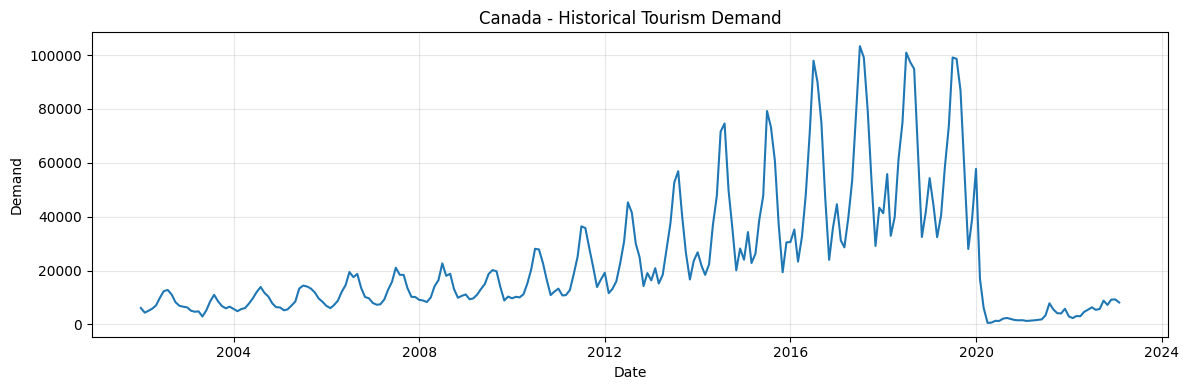

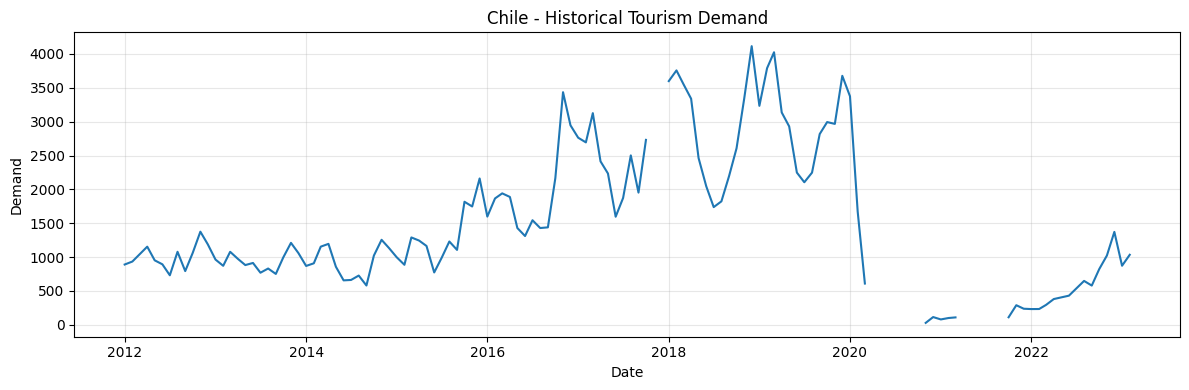

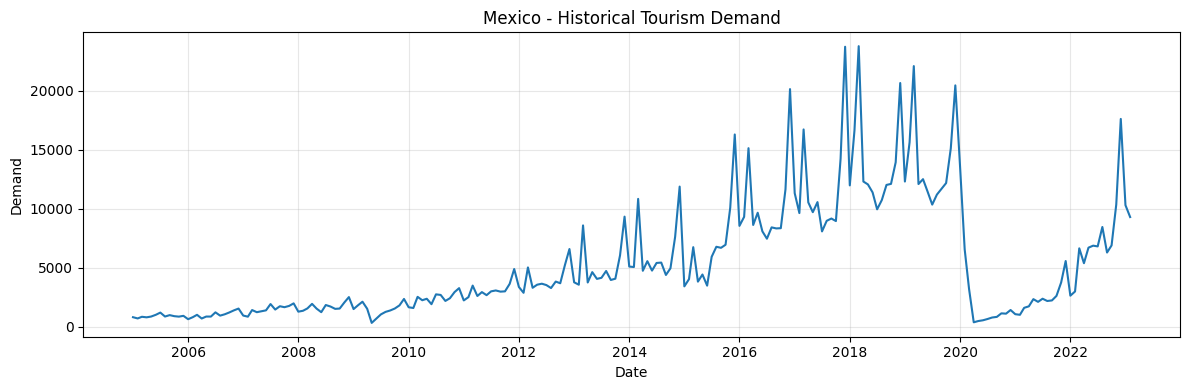

In [59]:
import matplotlib.pyplot as plt

# Visualizing the training history for the first 3 destination (just to have an idea about the trends)
for destination in DESTINATION_COLUMNS[:3]:
    plot_data = training_actual_wide_to_2023M02[["Date", destination]].copy()

    plot_data["_month_period"] = plot_data["Date"].map(month_label_to_period)
    plot_data["_month_date"] = plot_data["_month_period"].dt.to_timestamp()

    plt.figure(figsize=(12, 4))
    plt.plot(plot_data["_month_date"], plot_data[destination])

    plt.title(f"{destination} - Historical Tourism Demand")
    plt.xlabel("Date")
    plt.ylabel("Demand")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

-----------------------------

### Step 4 - Q1 General Naive-Lag Forecast Generator

## Part I: Forecast table generation and evaluation functions

Use the [A2 Function Examples Guide](SIG742-2026T2-A2-Function-Examples.md) for detailed Q1-Q3 input/output examples. Use the [A2 Forecast Measures Guide](SIG742-2026T2-A2-Forecast-Measures-Guide.md) for MASE/MAPE definitions and examples.

### Q1. General naive-lag forecast table generator [5 marks]

Implement `generate_naive_forecast_wide(historical_actual_wide, cutoff_label, forecast_months, required_destinations=None, lag=1, date_column="Date")`.

Requirements: accept a wide actual table; return a pandas DataFrame with exactly one row per requested month; use all destination columns when `required_destinations=None`; otherwise forecast exactly the supplied destinations; use only values available at or before `cutoff_label`; support positive integer `lag`, especially `lag=1` and `lag=12`; support arbitrary forecast months and all destinations; compute recursive lag forecasts in chronological month order; avoid string subtraction for month labels.

Return rows in the supplied `forecast_months` order. Return columns in the exact order `date_column`, followed by the inferred or supplied destination order. Do not return an index column, `model_label`, diagnostics, or other extra columns.

Lag rule: for forecast month `m`, use source month `m - lag`. If the source month is after the cutoff but has already been forecast, use that generated forecast recursively. If no source value is available, return `NaN` or raise a clear error.

**Required answer markers:** Do not delete, rename, edit, move, or reorder the Q1 START/END marker comments below. Write your response between them.

<!-- A2:ANSWER:Q1:START -->
Write any brief Q1 baseline-generator design notes here if needed. Delete this sentence before submission.
<!-- A2:ANSWER:Q1:END -->

#### Optional month-label helper example

This optional helper example only shows one way to convert labels such as `2023M03` into a month-aware representation. You may implement your own helper inside Q1. Do not use string subtraction for month arithmetic.


In [60]:
def month_label_to_period_example(month_label):
    """Optional example: convert a YYYYMmm label to a pandas monthly Period."""
    return pd.Period(str(month_label).replace("M", "-"), freq="M")


def period_to_month_label_example(period):
    """Optional example: convert a pandas monthly Period back to YYYYMmm."""
    return f"{period.year}M{period.month:02d}"

# Example only:
# month_label_to_period_example("2024M01") - 12


In [61]:
def generate_naive_forecast_wide(
    historical_actual_wide,
    cutoff_label,
    forecast_months,
    required_destinations=None,
    lag=1,
    date_column="Date",
):
    """Returning the required wide-format naive-lag forecast DataFrame."""

    # Checking that lag is a positive integer
    if not isinstance(lag, int) or lag <= 0:
        raise ValueError("lag must be a positive integer")

    # Using all destination columns when none are supplied
    if required_destinations is None:
        required_destinations = [
            column
            for column in historical_actual_wide.columns
            if column != date_column
        ]

    # Creating a working copy
    historical_data = historical_actual_wide.copy()

    # Converting month labels to monthly periods
    historical_data["_month_period"] = historical_data[date_column].map(
        month_label_to_period
    )

    cutoff_period = month_label_to_period(cutoff_label)

    # Keeping only actual values available up to the cutoff
    historical_data = historical_data[
        historical_data["_month_period"] <= cutoff_period
    ].copy()

    # Creating a lookup of observed historical values
    observed_values = {}

    for _, row in historical_data.iterrows():
        month_period = row["_month_period"]

        observed_values[month_period] = {
            destination: row[destination]
            for destination in required_destinations
        }

    # Creating storage for generated forecasts
    generated_values = {}

    # Forecasting in chronological order
    forecast_periods = sorted(
        [month_label_to_period(month) for month in forecast_months]
    )

    for forecast_period in forecast_periods:
        source_period = forecast_period - lag

        if source_period in observed_values:
            source_values = observed_values[source_period]

        elif source_period in generated_values:
            source_values = generated_values[source_period]

        else:
            source_values = {
                destination: np.nan
                for destination in required_destinations
            }

        generated_values[forecast_period] = source_values.copy()

    # Building the final forecast table in the requested month order
    forecast_rows = []

    for month in forecast_months:
        month_period = month_label_to_period(month)

        row = {date_column: month}

        for destination in required_destinations:
            row[destination] = generated_values[month_period][destination]

        forecast_rows.append(row)

    return pd.DataFrame(
        forecast_rows,
        columns=[date_column] + required_destinations,
    )

#### Q1 illustrative toy example only

Illustrative toy example only. Your real submission must apply the same logic to all 20 destinations and the required validation/final periods.

These toy checks are illustrative and not exhaustive. Passing these checks does not guarantee full marks; your functions must also satisfy the full assignment specification and work on the required validation and final forecast structures.


In [62]:
q1_toy_historical_actual_wide = pd.DataFrame({
    "Date": ["2022M03", "2022M04", "2022M05", "2022M06", "2022M07", "2023M01", "2023M02"],
    "Australia": [70, 75, 80, 85, 90, 95, 100],
    "Japan": [180, 190, 200, 210, 220, 230, 240],
})

q1_expected_lag1 = pd.DataFrame({
    "Date": ["2023M03", "2023M04", "2023M05"],
    "Australia": [100, 100, 100],
    "Japan": [240, 240, 240],
})

q1_expected_lag12 = pd.DataFrame({
    "Date": ["2023M03", "2023M04", "2023M05"],
    "Australia": [70, 75, 80],
    "Japan": [180, 190, 200],
})

# After implementing generate_naive_forecast_wide, set this to True and compare
# your toy outputs with q1_expected_lag1 and q1_expected_lag12.
RUN_Q1_TOY_CHECKS = True

if RUN_Q1_TOY_CHECKS:
    q1_lag1_output = generate_naive_forecast_wide(
        q1_toy_historical_actual_wide,
        cutoff_label="2023M02",
        forecast_months=["2023M03", "2023M04", "2023M05"],
        lag=1,
    )
    q1_lag12_output = generate_naive_forecast_wide(
        q1_toy_historical_actual_wide,
        cutoff_label="2023M02",
        forecast_months=["2023M03", "2023M04", "2023M05"],
        lag=12,
    )

    pd.testing.assert_frame_equal(
        q1_lag1_output.reset_index(drop=True),
        q1_expected_lag1,
        check_dtype=False,
    )
    pd.testing.assert_frame_equal(
        q1_lag12_output.reset_index(drop=True),
        q1_expected_lag12,
        check_dtype=False,
    )

In [63]:
# Checking the toy forecast outputs
display(q1_lag1_output)
display(q1_lag12_output)

,Date,Australia,Japan
0,2023M03,100,240
1,2023M04,100,240
2,2023M05,100,240


,Date,Australia,Japan
0,2023M03,70,180
1,2023M04,75,190
2,2023M05,80,200


#### Step 4 - Q1 Summary & Findings

We implemented the required `generate_naive_forecast_wide()` function and tested it using the starter notebook toy examples.

The function successfully supports both required naive forecasting approaches:

- `lag=1` produces a recursive carry-forward forecast, where future months use the most recently available or previously generated forecast value.
- `lag=12` produces a seasonal naive forecast, where each month uses the value from the same month in the previous year.

The provided toy checks completed without errors, confirming that the function returns the expected wide-format forecast structure and values for both lag configurations.

-----------------------

### Step 5 - Q2 Forecast and Actual Table Validation

### Q2. Forecast and actual table validation/alignment [5 marks]

Implement `validate_forecast_actual_wide(forecast_wide_df, actual_wide_df=None, required_months=None, required_destinations=None, date_column="Date")`.

`df` means a pandas DataFrame. Both inputs use a wide table: one row per month, one `Date` column, and one numeric column per destination. This is not a long table.

Modes: forecast-only mode (`actual_wide_df=None`) checks export readiness; forecast-vs-actual mode checks whether forecast and actual/result tables can align by `Date` and destination.

Requirements: check required `Date`, months, destination columns, row counts, duplicate dates, extra rows/columns, missing values, numeric values, finite values, and alignment when actuals are supplied. If `required_destinations=None`, infer destination columns from `forecast_wide_df`, but all-20 evidence must still match `REQUIRED_DESTINATIONS`.

Return a Python dictionary containing every key in `Q2_AUDIT_FIELDS`, in that order. In forecast-only mode, `can_align` and all actual-related fields must be `None`, not omitted. In forecast-vs-actual mode, `actual_row_count` counts actual rows after subsetting to `required_months`; `can_align` reports structural alignment; `is_valid` reports all applicable structure and value-quality checks. Duplicate counts count occurrences after the first occurrence.

**Required answer markers:** Do not delete, rename, edit, move, or reorder the Q2 START/END marker comments below. Write your response between them.

<!-- A2:ANSWER:Q2:START -->
Write any brief Q2 validation/alignment design notes here if needed. Delete this sentence before submission.
<!-- A2:ANSWER:Q2:END -->

In [64]:
def validate_forecast_actual_wide(
    forecast_wide_df,
    actual_wide_df=None,
    required_months=None,
    required_destinations=None,
    date_column="Date",
):
    """Return the fixed Q2 audit dictionary for wide-table validation.

    Populate every key in Q2_AUDIT_FIELDS. Forecast-only mode uses None for
    can_align and every actual-related field. Forecast-vs-actual mode subsets
    actual_wide_df to required_months before reporting actual_row_count and
    checking structural alignment.
    """
    audit = {
        "is_valid": False,
        "can_align": None if actual_wide_df is None else False,
        "forecast_row_count": len(forecast_wide_df),
        "actual_row_count": None,
        "expected_row_count": (
            len(required_months) if required_months is not None else None
        ),
        "missing_months_in_forecast": [],
        "missing_months_in_actual": None,
        "extra_months_in_forecast": [],
        "extra_months_in_actual_source": None,
        "missing_destinations_in_forecast": [],
        "missing_destinations_in_actual": None,
        "extra_columns_in_forecast": [],
        "duplicate_forecast_dates": 0,
        "duplicate_actual_dates": None,
        "missing_forecast_value_count": 0,
        "missing_actual_value_count": None,
        "nonnumeric_forecast_value_count": 0,
        "nonnumeric_actual_value_count": None,
        "nonfinite_forecast_value_count": 0,
        "nonfinite_actual_value_count": None,
    }

    # TODO: calculate and replace every applicable default value above.
    # Keep the keys and their order unchanged, then return the dictionary.
    #our introduced code below ------------------
    # Using the forecast destinations when none are supplied
    if required_destinations is None:
        required_destinations = [
            column
            for column in forecast_wide_df.columns
            if column != date_column
        ]

    required_destinations = list(required_destinations)

    # Checking whether the required Date column exists
    forecast_has_date = date_column in forecast_wide_df.columns
    actual_has_date = (
        actual_wide_df is not None
        and date_column in actual_wide_df.columns
    )

    # Determining the months we need to check
    if required_months is not None:
        task_months = list(required_months)
    elif forecast_has_date:
        task_months = forecast_wide_df[date_column].drop_duplicates().tolist()
    else:
        task_months = []

    # Checking forecast month coverage
    if forecast_has_date:
        forecast_dates = forecast_wide_df[date_column].tolist()

        if required_months is not None:
            audit["missing_months_in_forecast"] = [
                month for month in task_months
                if month not in forecast_dates
            ]

            audit["extra_months_in_forecast"] = list(dict.fromkeys([
                month for month in forecast_dates
                if month not in task_months
            ]))

        audit["duplicate_forecast_dates"] = int(
            forecast_wide_df[date_column].duplicated().sum()
        )

        if required_months is not None:
            forecast_scope = forecast_wide_df[
                forecast_wide_df[date_column].isin(task_months)
            ].copy()
        else:
            forecast_scope = forecast_wide_df.copy()

    else:
        audit["missing_months_in_forecast"] = (
            task_months.copy()
            if required_months is not None
            else []
        )
        forecast_scope = forecast_wide_df.iloc[0:0].copy()

    # Checking forecast destination columns
    audit["missing_destinations_in_forecast"] = [
        destination for destination in required_destinations
        if destination not in forecast_wide_df.columns
    ]

    audit["extra_columns_in_forecast"] = [
        column for column in forecast_wide_df.columns
        if column != date_column
        and column not in required_destinations
    ]

    # Checking forecast value quality
    present_forecast_destinations = [
        destination for destination in required_destinations
        if destination in forecast_scope.columns
    ]

    if present_forecast_destinations:
        forecast_values = forecast_scope[
            present_forecast_destinations
        ]

        forecast_numeric = forecast_values.apply(
            pd.to_numeric,
            errors="coerce"
        )

        audit["missing_forecast_value_count"] = int(
            forecast_values.isna().sum().sum()
        )

        audit["nonnumeric_forecast_value_count"] = int(
            (
                forecast_values.notna()
                & forecast_numeric.isna()
            ).sum().sum()
        )

        audit["nonfinite_forecast_value_count"] = int(
            np.isinf(forecast_numeric.to_numpy()).sum()
        )

    # Checking actual data when supplied
    if actual_wide_df is not None:

        if actual_has_date:
            actual_dates = actual_wide_df[date_column].tolist()

            audit["missing_months_in_actual"] = [
                month for month in task_months
                if month not in actual_dates
            ]

            audit["extra_months_in_actual_source"] = list(dict.fromkeys([
                month for month in actual_dates
                if month not in task_months
            ]))

            actual_scope = actual_wide_df[
                actual_wide_df[date_column].isin(task_months)
            ].copy()

            audit["actual_row_count"] = len(actual_scope)

            audit["duplicate_actual_dates"] = int(
                actual_scope[date_column].duplicated().sum()
            )

        else:
            actual_scope = actual_wide_df.iloc[0:0].copy()
            audit["actual_row_count"] = 0
            audit["missing_months_in_actual"] = task_months.copy()
            audit["extra_months_in_actual_source"] = []

        # Checking required actual destinations
        audit["missing_destinations_in_actual"] = [
            destination for destination in required_destinations
            if destination not in actual_wide_df.columns
        ]

        # Checking actual value quality
        present_actual_destinations = [
            destination for destination in required_destinations
            if destination in actual_scope.columns
        ]

        if present_actual_destinations:
            actual_values = actual_scope[
                present_actual_destinations
            ]

            actual_numeric = actual_values.apply(
                pd.to_numeric,
                errors="coerce"
            )

            audit["missing_actual_value_count"] = int(
                actual_values.isna().sum().sum()
            )

            audit["nonnumeric_actual_value_count"] = int(
                (
                    actual_values.notna()
                    & actual_numeric.isna()
                ).sum().sum()
            )

            audit["nonfinite_actual_value_count"] = int(
                np.isinf(actual_numeric.to_numpy()).sum()
            )

        # Checking whether forecast and actual tables can align
        audit["can_align"] = bool(
            forecast_has_date
            and actual_has_date
            and not audit["missing_months_in_forecast"]
            and not audit["missing_months_in_actual"]
            and not audit["missing_destinations_in_forecast"]
            and not audit["missing_destinations_in_actual"]
            and audit["duplicate_forecast_dates"] == 0
            and audit["duplicate_actual_dates"] == 0
        )

    # Checking whether the forecast table itself is valid
    forecast_valid = bool(
        forecast_has_date
        and not audit["missing_months_in_forecast"]
        and not audit["extra_months_in_forecast"]
        and not audit["missing_destinations_in_forecast"]
        and not audit["extra_columns_in_forecast"]
        and audit["duplicate_forecast_dates"] == 0
        and audit["missing_forecast_value_count"] == 0
        and audit["nonnumeric_forecast_value_count"] == 0
        and audit["nonfinite_forecast_value_count"] == 0
        and (
            audit["expected_row_count"] is None
            or audit["forecast_row_count"]
            == audit["expected_row_count"]
        )
    )

    # Checking actual quality when actual data is supplied
    if actual_wide_df is None:
        audit["is_valid"] = forecast_valid

    else:
        actual_valid = bool(
            actual_has_date
            and not audit["missing_months_in_actual"]
            and not audit["missing_destinations_in_actual"]
            and audit["duplicate_actual_dates"] == 0
            and audit["missing_actual_value_count"] == 0
            and audit["nonnumeric_actual_value_count"] == 0
            and audit["nonfinite_actual_value_count"] == 0
        )

        audit["is_valid"] = bool(
            forecast_valid
            and actual_valid
            and audit["can_align"]
        )
    return audit

#### Q2 illustrative toy examples only

Illustrative toy examples only. Your real submission must apply the same logic to all 20 destinations and the required validation/final periods.

The examples check the fixed dictionary schema in forecast-only and forecast-vs-actual modes. They are not exhaustive; your function must still satisfy the full assignment specification.

In [65]:
q2_valid_forecast_wide_df = pd.DataFrame({
    "Date": ["2023M08", "2023M09"],
    "Australia": [12345.0, 12400.0],
    "Japan": [23456.0, 23500.0],
})

q2_bad_forecast_wide_df = pd.DataFrame({
    "Date": ["2023M08", "2023M08"],
    "Australia": [12345.0, "not_a_number"],
})

q2_actual_source_wide_df = pd.DataFrame({
    "Date": ["2023M07", "2023M08", "2023M09"],
    "Australia": [12200.0, 12350.0, 12420.0],
    "Japan": [23200.0, 23480.0, 23540.0],
})

q2_required_months = ["2023M08", "2023M09"]
q2_required_destinations = ["Australia", "Japan"]

q2_expected_valid_forecast_only_audit = {
    "is_valid": True,
    "can_align": None,
    "forecast_row_count": 2,
    "actual_row_count": None,
    "expected_row_count": 2,
    "missing_months_in_forecast": [],
    "missing_months_in_actual": None,
    "extra_months_in_forecast": [],
    "extra_months_in_actual_source": None,
    "missing_destinations_in_forecast": [],
    "missing_destinations_in_actual": None,
    "extra_columns_in_forecast": [],
    "duplicate_forecast_dates": 0,
    "duplicate_actual_dates": None,
    "missing_forecast_value_count": 0,
    "missing_actual_value_count": None,
    "nonnumeric_forecast_value_count": 0,
    "nonnumeric_actual_value_count": None,
    "nonfinite_forecast_value_count": 0,
    "nonfinite_actual_value_count": None,
}

q2_expected_invalid_forecast_only_audit = {
    "is_valid": False,
    "can_align": None,
    "forecast_row_count": 2,
    "actual_row_count": None,
    "expected_row_count": 2,
    "missing_months_in_forecast": ["2023M09"],
    "missing_months_in_actual": None,
    "extra_months_in_forecast": [],
    "extra_months_in_actual_source": None,
    "missing_destinations_in_forecast": ["Japan"],
    "missing_destinations_in_actual": None,
    "extra_columns_in_forecast": [],
    "duplicate_forecast_dates": 1,
    "duplicate_actual_dates": None,
    "missing_forecast_value_count": 0,
    "missing_actual_value_count": None,
    "nonnumeric_forecast_value_count": 1,
    "nonnumeric_actual_value_count": None,
    "nonfinite_forecast_value_count": 0,
    "nonfinite_actual_value_count": None,
}

q2_expected_valid_alignment_audit = {
    "is_valid": True,
    "can_align": True,
    "forecast_row_count": 2,
    "actual_row_count": 2,
    "expected_row_count": 2,
    "missing_months_in_forecast": [],
    "missing_months_in_actual": [],
    "extra_months_in_forecast": [],
    "extra_months_in_actual_source": ["2023M07"],
    "missing_destinations_in_forecast": [],
    "missing_destinations_in_actual": [],
    "extra_columns_in_forecast": [],
    "duplicate_forecast_dates": 0,
    "duplicate_actual_dates": 0,
    "missing_forecast_value_count": 0,
    "missing_actual_value_count": 0,
    "nonnumeric_forecast_value_count": 0,
    "nonnumeric_actual_value_count": 0,
    "nonfinite_forecast_value_count": 0,
    "nonfinite_actual_value_count": 0,
}

# After implementing validate_forecast_actual_wide, set this to True.
RUN_Q2_TOY_CHECKS = True

if RUN_Q2_TOY_CHECKS:
    q2_valid_forecast_only_audit = validate_forecast_actual_wide(
        q2_valid_forecast_wide_df,
        actual_wide_df=None,
        required_months=q2_required_months,
        required_destinations=q2_required_destinations,
    )
    q2_invalid_forecast_only_audit = validate_forecast_actual_wide(
        q2_bad_forecast_wide_df,
        actual_wide_df=None,
        required_months=q2_required_months,
        required_destinations=q2_required_destinations,
    )
    q2_valid_alignment_audit = validate_forecast_actual_wide(
        q2_valid_forecast_wide_df,
        actual_wide_df=q2_actual_source_wide_df,
        required_months=q2_required_months,
        required_destinations=q2_required_destinations,
    )

    q2_toy_pairs = [
        (q2_valid_forecast_only_audit, q2_expected_valid_forecast_only_audit),
        (q2_invalid_forecast_only_audit, q2_expected_invalid_forecast_only_audit),
        (q2_valid_alignment_audit, q2_expected_valid_alignment_audit),
    ]
    for observed_audit, expected_audit in q2_toy_pairs:
        assert isinstance(observed_audit, dict)
        assert list(observed_audit) == Q2_AUDIT_FIELDS
        assert observed_audit == expected_audit

In [66]:
# Checking the Q2 toy audit outputs
display(q2_valid_forecast_only_audit)
display(q2_invalid_forecast_only_audit)
display(q2_valid_alignment_audit)

{'is_valid': True,
 'can_align': None,
 'forecast_row_count': 2,
 'actual_row_count': None,
 'expected_row_count': 2,
 'missing_months_in_forecast': [],
 'missing_months_in_actual': None,
 'extra_months_in_forecast': [],
 'extra_months_in_actual_source': None,
 'missing_destinations_in_forecast': [],
 'missing_destinations_in_actual': None,
 'extra_columns_in_forecast': [],
 'duplicate_forecast_dates': 0,
 'duplicate_actual_dates': None,
 'missing_forecast_value_count': 0,
 'missing_actual_value_count': None,
 'nonnumeric_forecast_value_count': 0,
 'nonnumeric_actual_value_count': None,
 'nonfinite_forecast_value_count': 0,
 'nonfinite_actual_value_count': None}

{'is_valid': False,
 'can_align': None,
 'forecast_row_count': 2,
 'actual_row_count': None,
 'expected_row_count': 2,
 'missing_months_in_forecast': ['2023M09'],
 'missing_months_in_actual': None,
 'extra_months_in_forecast': [],
 'extra_months_in_actual_source': None,
 'missing_destinations_in_forecast': ['Japan'],
 'missing_destinations_in_actual': None,
 'extra_columns_in_forecast': [],
 'duplicate_forecast_dates': 1,
 'duplicate_actual_dates': None,
 'missing_forecast_value_count': 0,
 'missing_actual_value_count': None,
 'nonnumeric_forecast_value_count': 1,
 'nonnumeric_actual_value_count': None,
 'nonfinite_forecast_value_count': 0,
 'nonfinite_actual_value_count': None}

{'is_valid': True,
 'can_align': True,
 'forecast_row_count': 2,
 'actual_row_count': 2,
 'expected_row_count': 2,
 'missing_months_in_forecast': [],
 'missing_months_in_actual': [],
 'extra_months_in_forecast': [],
 'extra_months_in_actual_source': ['2023M07'],
 'missing_destinations_in_forecast': [],
 'missing_destinations_in_actual': [],
 'extra_columns_in_forecast': [],
 'duplicate_forecast_dates': 0,
 'duplicate_actual_dates': 0,
 'missing_forecast_value_count': 0,
 'missing_actual_value_count': 0,
 'nonnumeric_forecast_value_count': 0,
 'nonnumeric_actual_value_count': 0,
 'nonfinite_forecast_value_count': 0,
 'nonfinite_actual_value_count': 0}

#### Step 5 - Q2 Summary & Findings

We implemented the required `validate_forecast_actual_wide()` function to check the structural and value quality of forecast tables before evaluation.

The validator supports both required modes:

- Forecast-only validation checks required months and destinations, duplicate dates, missing values, numeric values, finite values, and unexpected rows or columns.
- Forecast-versus-actual validation additionally checks whether forecast and actual tables can be aligned correctly by month and destination.

The provided toy tests passed successfully. The function correctly accepted valid forecast tables, identified the expected problems in an intentionally invalid table, and confirmed that forecast and actual tables can still align when the actual source contains additional historical months outside the required evaluation period.

### Q3. Forecast accuracy measures from forecast and actual tables [5 marks]

Implement `evaluate_forecast_wide(forecast_wide_df, actual_wide_df, training_actual_wide_df, start_month, end_month, required_destinations=None, naive_lag=1, date_column="Date")`.

Use the [A2 Forecast Measures Guide](SIG742-2026T2-A2-Forecast-Measures-Guide.md). Both MASE and MAPE are required.

Requirements: align forecast and actual/result tables by `Date` and destination; work destination by destination; select months from `start_month` to `end_month`; evaluate all forecast destination columns when `required_destinations=None`; compute MAE, MASE, MAPE, denominator, `n`, `n_denominator_pairs`, `mase_available`, and `denominator_warning`; keep MASE/MAPE separately identifiable; sort training actuals chronologically; use all valid lagged training pairs for each destination's MASE denominator; use `naive_lag=1` for official validation unless stated otherwise; handle missing values, nonfinite values, zero actuals for MAPE, and unavailable denominators explicitly.

Return exactly `(destination_metrics, aggregate_metrics)`. `destination_metrics` must be a pandas DataFrame with columns in `DESTINATION_METRIC_COLUMNS`. `aggregate_metrics` must be a Python dictionary with exactly the keys in `AGGREGATE_METRIC_FIELDS`.

Do not fill missing denominators with zero. Do not use validation actuals or assessment-period actual/result values to repair denominators. `lag=12` baseline forecasts are for comparison; they are not the official MASE denominator. Aggregate measures are unweighted summaries of destination-level measures unless otherwise stated.

**Required answer markers:** Do not delete, rename, edit, move, or reorder the Q3 START/END marker comments below. Write your response between them.

<!-- A2:ANSWER:Q3:START -->
Write any brief Q3 performance-measure design notes here if needed. Delete this sentence before submission.
<!-- A2:ANSWER:Q3:END -->

### Step 6 - Q3 Forecast Accuracy Evaluation

In [67]:
def evaluate_forecast_wide(
    forecast_wide_df,
    actual_wide_df,
    training_actual_wide_df,
    start_month,
    end_month,
    required_destinations=None,
    naive_lag=1,
    date_column="Date",
):
    """Return (destination_metrics, aggregate_metrics).

    destination_metrics is a DataFrame using DESTINATION_METRIC_COLUMNS.
    aggregate_metrics is a dictionary using AGGREGATE_METRIC_FIELDS.
    Sort training_actual_wide_df chronologically before computing all valid
    denominator pairs. If required_destinations is None, evaluate all forecast
    columns except date_column; otherwise evaluate exactly those destinations.
    """
    destination_metrics = pd.DataFrame(columns=DESTINATION_METRIC_COLUMNS)
    aggregate_metrics = {
        field: None for field in AGGREGATE_METRIC_FIELDS
    }

    #our introduced code below -------------------
        # Checking the denominator lag
    if not isinstance(naive_lag, int) or naive_lag <= 0:
        raise ValueError("naive_lag must be a positive integer")

    # Using all forecast destinations when none are supplied
    if required_destinations is None:
        required_destinations = [
            column
            for column in forecast_wide_df.columns
            if column != date_column
        ]

    required_destinations = list(required_destinations)

    # Converting the evaluation boundaries to monthly periods
    start_period = month_label_to_period(start_month)
    end_period = month_label_to_period(end_month)

    # Creating working copies
    forecast_data = forecast_wide_df.copy()
    actual_data = actual_wide_df.copy()
    training_data = training_actual_wide_df.copy()

    # Converting month labels for alignment and sorting
    forecast_data["_month_period"] = (
        forecast_data[date_column].map(month_label_to_period)
    )

    actual_data["_month_period"] = (
        actual_data[date_column].map(month_label_to_period)
    )

    training_data["_month_period"] = (
        training_data[date_column].map(month_label_to_period)
    )

    # Keeping only the requested evaluation period
    forecast_data = forecast_data[
        forecast_data["_month_period"].between(
            start_period,
            end_period
        )
    ].copy()

    actual_data = actual_data[
        actual_data["_month_period"].between(
            start_period,
            end_period
        )
    ].copy()

    # Sorting the training history chronologically
    training_data = (
        training_data
        .sort_values("_month_period")
        .reset_index(drop=True)
    )

    metric_rows = []

    # Calculating the measures destination by destination
    for destination in required_destinations:

        # Aligning forecast and actual values by month
        aligned = pd.merge(
            forecast_data[["_month_period", destination]],
            actual_data[["_month_period", destination]],
            on="_month_period",
            how="inner",
            suffixes=("_forecast", "_actual"),
        )

        forecast_values = pd.to_numeric(
            aligned[f"{destination}_forecast"],
            errors="coerce",
        ).to_numpy(dtype=float)

        actual_values = pd.to_numeric(
            aligned[f"{destination}_actual"],
            errors="coerce",
        ).to_numpy(dtype=float)

        # Calculating MAE from valid forecast-actual rows
        valid_rows = (
            np.isfinite(forecast_values)
            & np.isfinite(actual_values)
        )

        n = int(valid_rows.sum())

        if n > 0:
            mae = float(
                np.mean(
                    np.abs(
                        actual_values[valid_rows]
                        - forecast_values[valid_rows]
                    )
                )
            )
        else:
            mae = np.nan

        # Calculating MAPE while excluding zero actual values
        valid_mape_rows = (
            valid_rows
            & (actual_values != 0)
        )

        if valid_mape_rows.any():
            mape = float(
                np.mean(
                    np.abs(
                        (
                            actual_values[valid_mape_rows]
                            - forecast_values[valid_mape_rows]
                        )
                        / actual_values[valid_mape_rows]
                    )
                )
                * 100
            )
        else:
            mape = np.nan

        # Calculating the MASE denominator from training history
        training_values = pd.to_numeric(
            training_data[destination],
            errors="coerce",
        ).to_numpy(dtype=float)

        left_values = training_values[naive_lag:]
        right_values = training_values[:-naive_lag]

        valid_pairs = (
            np.isfinite(left_values)
            & np.isfinite(right_values)
        )

        denominator_differences = np.abs(
            left_values[valid_pairs]
            - right_values[valid_pairs]
        )

        n_denominator_pairs = len(denominator_differences)

        if n_denominator_pairs > 0:
            denominator = float(
                np.mean(denominator_differences)
            )
        else:
            denominator = np.nan

        # Checking whether MASE can be calculated
        if (
            n == 0
            or not np.isfinite(mae)
            or n_denominator_pairs == 0
            or not np.isfinite(denominator)
            or denominator <= 0
        ):
            mase = np.nan
            mase_available = False
            denominator_warning = True
        else:
            mase = float(mae / denominator)
            mase_available = True
            denominator_warning = False

        metric_rows.append({
            "destination": destination,
            "n": n,
            "mae": mae,
            "mase": mase,
            "mape": mape,
            "denominator": denominator,
            "n_denominator_pairs": n_denominator_pairs,
            "mase_available": mase_available,
            "denominator_warning": denominator_warning,
        })

    # Creating the destination-level results table
    destination_metrics = pd.DataFrame(
        metric_rows,
        columns=DESTINATION_METRIC_COLUMNS,
    )

    # Creating the overall unweighted summary
    aggregate_metrics = {
        "n_destinations": len(destination_metrics),
        "mean_mase": destination_metrics["mase"].mean(),
        "median_mase": destination_metrics["mase"].median(),
        "mean_mape": destination_metrics["mape"].mean(),
    }
    return destination_metrics, aggregate_metrics

#### Q3 illustrative toy example only

Illustrative toy example only. Your real submission must apply the same logic to all 20 destinations and the required validation/final periods.

These toy checks are illustrative and not exhaustive. Passing these checks does not guarantee full marks; your functions must also satisfy the full assignment specification and work on the required validation and final forecast structures.

Expected approximate values for this toy example: Australia MASE approximately 2.67 and MAPE 16.08%, Japan MASE = 1.00 and MAPE 8.63%, aggregate mean MASE approximately 1.83, and aggregate mean MAPE approximately 12.36%. Calculate aggregates from unrounded destination-level values, then round only for display.


In [68]:
q3_toy_validation_forecast_wide = pd.DataFrame({
    "Date": ["2023M03", "2023M04"],
    "Australia": [100, 100],
    "Japan": [200, 220],
})

q3_toy_validation_actual_wide = pd.DataFrame({
    "Date": ["2023M03", "2023M04"],
    "Australia": [110, 130],
    "Japan": [190, 250],
})

q3_toy_training_actual_wide = pd.DataFrame({
    "Date": ["2022M12", "2023M01", "2023M02"],
    "Australia": [95, 105, 100],
    "Japan": [180, 210, 200],
})

q3_expected_destination_metrics = pd.DataFrame({
    "destination": ["Australia", "Japan"],
    "n": [2, 2],
    "mae": [20.0, 20.0],
    "mase": [2.67, 1.00],
    "mape": [16.08, 8.63],
    "denominator": [7.5, 20.0],
    "n_denominator_pairs": [2, 2],
    "mase_available": [True, True],
    "denominator_warning": [False, False],
})

q3_expected_aggregate_metrics = {
    "n_destinations": 2,
    "mean_mase": 1.83,
    "median_mase": 1.83,
    "mean_mape": 12.36,
}

q3_missing_denominator_training_actual = pd.DataFrame({
    "Date": ["2022M10", "2022M11", "2022M12", "2023M01", "2023M02"],
    "Australia": [80, np.nan, 95, 105, 100],
})

# The toy training table has three rows, so its denominator has two valid lag-1
# pairs. In the real assignment, use all valid lagged pairs available up to the
# relevant cutoff; do not truncate the window to the forecast-horizon length.
#
# For q3_missing_denominator_training_actual, valid lag-1 pairs are
# 2023M01-2022M12 and 2023M02-2023M01, so n_denominator_pairs should be 2.
#
# After implementing evaluate_forecast_wide, set this to True.
RUN_Q3_TOY_CHECKS = True

if RUN_Q3_TOY_CHECKS:
    q3_toy_destination_metrics, q3_toy_aggregate_metrics = evaluate_forecast_wide(
        q3_toy_validation_forecast_wide,
        q3_toy_validation_actual_wide,
        q3_toy_training_actual_wide,
        start_month="2023M03",
        end_month="2023M04",
        naive_lag=1,
    )

    assert isinstance(q3_toy_destination_metrics, pd.DataFrame)
    assert list(q3_toy_destination_metrics.columns) == DESTINATION_METRIC_COLUMNS
    assert isinstance(q3_toy_aggregate_metrics, dict)
    assert list(q3_toy_aggregate_metrics) == AGGREGATE_METRIC_FIELDS
    assert list(q3_toy_destination_metrics["destination"]) == ["Australia", "Japan"]
    for column in ["mae", "mase", "mape", "denominator"]:
        assert np.allclose(
            q3_toy_destination_metrics[column],
            q3_expected_destination_metrics[column],
            rtol=0.01,
            atol=0.01,
        )
    for field, expected_value in q3_expected_aggregate_metrics.items():
        assert np.isclose(q3_toy_aggregate_metrics[field], expected_value, atol=0.01)

In [69]:
# Checking the Q3 toy evaluation outputs
display(q3_toy_destination_metrics)
display(q3_toy_aggregate_metrics)

,destination,n,mae,mase,mape,denominator,n_denominator_pairs,mase_available,denominator_warning
0,Australia,2,20.0,2.666667,16.083916,7.5,2,True,False
1,Japan,2,20.0,1.000000,8.631579,20.0,2,True,False


{'n_destinations': 2,
 'mean_mase': np.float64(1.8333333333333333),
 'median_mase': np.float64(1.8333333333333333),
 'mean_mape': np.float64(12.357747515642252)}

--------------------------

### Step 7 - Part I Integrated Evidence

To make things readable and easy to follow, we have broken down this Step (The Integrated Evidence) into multiple sub steps as follows:
- 7.1: Generating the Two Real Baseline Forecasts
- 7.2: Auditing both baseline forecasts
- 7.3: Evaluating both baselines
- 7.4: Building the required evidence tables
- 7.5: Finally visualizing some selected markets' forecasts (actuals, lag_1 and lag_2)

### Part I integrated evidence

Use Q1-Q3 together to create `baseline_validation_comparison` and `baseline_validation_summary` for both `naive_lag1` and `naive_lag12` over validation months `2023M03` to `2023M07` for all 20 destinations.

Integrated evidence does not carry separate marks. It shows that Q1-Q3 work together and provides baseline evidence required for Q4.

Use `evaluate_forecast_wide(..., naive_lag=1)` for official MASE denominator scaling for both baselines. The `lag` column describes forecast generation, not the denominator used for official MASE.

`baseline_validation_comparison` must include `model_label`, `lag`, `destination`, `n`, `mae`, `mase`, `mape`, `denominator`, `n_denominator_pairs`, `mase_available`, and `denominator_warning`.

`baseline_validation_summary` must include `model_label`, `lag`, `n_destinations`, `mean_mase`, `median_mase`, and `mean_mape`.

Both tables must be visible in the notebook and exported PDF.


In [70]:
# Part I integrated evidence workflow skeleton.
# 1. Create training_actual_wide_to_2023M02 and validation_actual_wide_2023M03_2023M07.
# 2. Generate baseline_lag1_validation_forecast_wide with lag=1.
# 3. Generate baseline_lag12_validation_forecast_wide with lag=12.
# 4. Audit both baselines against validation_actual_wide_2023M03_2023M07.
# 5. Evaluate both baselines using evaluate_forecast_wide(..., naive_lag=1).
# 6. Combine destination-level results into baseline_validation_comparison.
# 7. Summarise into baseline_validation_summary.

baseline_lag1_validation_forecast_wide = None  # TODO: create with generate_naive_forecast_wide(..., lag=1).
baseline_lag12_validation_forecast_wide = None  # TODO: create with generate_naive_forecast_wide(..., lag=12).
baseline_lag1_validation_audit = None  # TODO: validate lag=1 forecast against validation actuals.
baseline_lag12_validation_audit = None  # TODO: validate lag=12 forecast against validation actuals.
baseline_validation_comparison = None  # TODO: destination-level measures for both baselines with BASELINE_COMPARISON_COLUMNS.
baseline_validation_summary = None  # TODO: aggregate measures for both baselines with BASELINE_SUMMARY_COLUMNS.


#### 7.1 - Generate the Required Baseline Forecasts

In [75]:
# Building the lag-1 baseline forecast for the validation period
baseline_lag1_validation_forecast_wide = generate_naive_forecast_wide(
    historical_actual_wide=training_actual_wide_to_2023M02,
    cutoff_label=TRAIN_END,
    forecast_months=VALIDATION_MONTHS,
    required_destinations=REQUIRED_DESTINATIONS,
    lag=1,
    date_column="Date",
)

# Building the lag-12 baseline forecast for the validation period
baseline_lag12_validation_forecast_wide = generate_naive_forecast_wide(
    historical_actual_wide=training_actual_wide_to_2023M02,
    cutoff_label=TRAIN_END,
    forecast_months=VALIDATION_MONTHS,
    required_destinations=REQUIRED_DESTINATIONS,
    lag=12,
    date_column="Date",
)

In [76]:
#verifying the baselines
print("Lag-1 shape:", baseline_lag1_validation_forecast_wide.shape)
print("Lag-12 shape:", baseline_lag12_validation_forecast_wide.shape)

display(
    baseline_lag1_validation_forecast_wide[
        ["Date", "Australia", "Japan", "Chile"]
    ]
)

display(
    baseline_lag12_validation_forecast_wide[
        ["Date", "Australia", "Japan", "Chile"]
    ]
)

Lag-1 shape: (5, 21)
Lag-12 shape: (5, 21)


,Date,Australia,Japan,Chile
0,2023M03,40430.0,36200.0,1034.0
1,2023M04,40430.0,36200.0,1034.0
2,2023M05,40430.0,36200.0,1034.0
3,2023M06,40430.0,36200.0,1034.0
4,2023M07,40430.0,36200.0,1034.0


,Date,Australia,Japan,Chile
0,2023M03,5130.0,9799.0,294.0
1,2023M04,3550.0,22371.0,380.0
2,2023M05,4250.0,17643.0,404.0
3,2023M06,6550.0,14657.0,430.0
4,2023M07,12390.0,14803.0,537.0


#### 7.2 - Audit the Baseline Forecasts

In [77]:
# Auditing the lag-1 baseline forecast
baseline_lag1_validation_audit = validate_forecast_actual_wide(
    forecast_wide_df=baseline_lag1_validation_forecast_wide,
    actual_wide_df=validation_actual_wide_2023M03_2023M07,
    required_months=VALIDATION_MONTHS,
    required_destinations=REQUIRED_DESTINATIONS,
    date_column="Date",
)

# Auditing the lag-12 baseline forecast
baseline_lag12_validation_audit = validate_forecast_actual_wide(
    forecast_wide_df=baseline_lag12_validation_forecast_wide,
    actual_wide_df=validation_actual_wide_2023M03_2023M07,
    required_months=VALIDATION_MONTHS,
    required_destinations=REQUIRED_DESTINATIONS,
    date_column="Date",
)

# Checking the audit results
display(baseline_lag1_validation_audit)
display(baseline_lag12_validation_audit)

{'is_valid': True,
 'can_align': True,
 'forecast_row_count': 5,
 'actual_row_count': 5,
 'expected_row_count': 5,
 'missing_months_in_forecast': [],
 'missing_months_in_actual': [],
 'extra_months_in_forecast': [],
 'extra_months_in_actual_source': [],
 'missing_destinations_in_forecast': [],
 'missing_destinations_in_actual': [],
 'extra_columns_in_forecast': [],
 'duplicate_forecast_dates': 0,
 'duplicate_actual_dates': 0,
 'missing_forecast_value_count': 0,
 'missing_actual_value_count': 0,
 'nonnumeric_forecast_value_count': 0,
 'nonnumeric_actual_value_count': 0,
 'nonfinite_forecast_value_count': 0,
 'nonfinite_actual_value_count': 0}

{'is_valid': True,
 'can_align': True,
 'forecast_row_count': 5,
 'actual_row_count': 5,
 'expected_row_count': 5,
 'missing_months_in_forecast': [],
 'missing_months_in_actual': [],
 'extra_months_in_forecast': [],
 'extra_months_in_actual_source': [],
 'missing_destinations_in_forecast': [],
 'missing_destinations_in_actual': [],
 'extra_columns_in_forecast': [],
 'duplicate_forecast_dates': 0,
 'duplicate_actual_dates': 0,
 'missing_forecast_value_count': 0,
 'missing_actual_value_count': 0,
 'nonnumeric_forecast_value_count': 0,
 'nonnumeric_actual_value_count': 0,
 'nonfinite_forecast_value_count': 0,
 'nonfinite_actual_value_count': 0}

#### 7.3 - Evaluate the Baseline Forecasts

In [78]:
# Evaluating the lag-1 baseline forecast
lag1_destination_metrics, lag1_aggregate_metrics = evaluate_forecast_wide(
    forecast_wide_df=baseline_lag1_validation_forecast_wide,
    actual_wide_df=validation_actual_wide_2023M03_2023M07,
    training_actual_wide_df=training_actual_wide_to_2023M02,
    start_month=VALIDATION_START,
    end_month=VALIDATION_END,
    required_destinations=REQUIRED_DESTINATIONS,
    naive_lag=1,
    date_column="Date",
)

# Evaluating the lag-12 baseline forecast
lag12_destination_metrics, lag12_aggregate_metrics = evaluate_forecast_wide(
    forecast_wide_df=baseline_lag12_validation_forecast_wide,
    actual_wide_df=validation_actual_wide_2023M03_2023M07,
    training_actual_wide_df=training_actual_wide_to_2023M02,
    start_month=VALIDATION_START,
    end_month=VALIDATION_END,
    required_destinations=REQUIRED_DESTINATIONS,
    naive_lag=1,
    date_column="Date",
)

In [79]:
# Checking the baseline evaluation results
print("Lag-1 metrics shape:", lag1_destination_metrics.shape)
print("Lag-12 metrics shape:", lag12_destination_metrics.shape)

display(lag1_destination_metrics.head())
display(lag12_destination_metrics.head())

print("\nLag-1 aggregate metrics:")
display(lag1_aggregate_metrics)

print("\nLag-12 aggregate metrics:")
display(lag12_aggregate_metrics)

Lag-1 metrics shape: (20, 9)
Lag-12 metrics shape: (20, 9)


,destination,n,mae,mase,mape,denominator,n_denominator_pairs,mase_available,denominator_warning
0,Canada,5,8453.4,1.353923,44.825228,6243.636364,253,True,False
1,Chile,5,397.6,1.396451,27.106541,284.721739,115,True,False
2,Mexico,5,2637.8,1.654912,21.466003,1593.921659,217,True,False
3,Taiwan China,5,6878.6,0.280336,37.065578,24537.011429,175,True,False
4,Hong Kong China,5,1229352.2,5.208431,51.651148,236031.183391,289,True,False


,destination,n,mae,mase,mape,denominator,n_denominator_pairs,mase_available,denominator_warning
0,Canada,5,12072.2,1.933521,72.313340,6243.636364,253,True,False
1,Chile,5,1022.6,3.591577,70.906929,284.721739,115,True,False
2,Mexico,5,5456.4,3.423255,45.285123,1593.921659,217,True,False
3,Taiwan China,5,15136.6,0.616888,93.100343,24537.011429,175,True,False
4,Hong Kong China,5,2320349.4,9.830690,99.235183,236031.183391,289,True,False



Lag-1 aggregate metrics:


{'n_destinations': 20,
 'mean_mase': np.float64(2.6706784523596956),
 'median_mase': np.float64(1.6963719005002749),
 'mean_mape': np.float64(48.057644590753156)}


Lag-12 aggregate metrics:


{'n_destinations': 20,
 'mean_mase': np.float64(4.409590680755385),
 'median_mase': np.float64(3.8286562961778934),
 'mean_mape': np.float64(77.89872819510933)}

#### 7.4 - Build the Baseline Evidence Tables

In [80]:
# Building the destination-level baseline comparison table
lag1_comparison = lag1_destination_metrics.copy()
lag1_comparison.insert(0, "lag", 1)
lag1_comparison.insert(0, "model_label", "naive_lag1")

lag12_comparison = lag12_destination_metrics.copy()
lag12_comparison.insert(0, "lag", 12)
lag12_comparison.insert(0, "model_label", "naive_lag12")

baseline_validation_comparison = pd.concat(
    [lag1_comparison, lag12_comparison],
    ignore_index=True,
)[BASELINE_COMPARISON_COLUMNS]

# Building the aggregate baseline summary table
baseline_validation_summary = pd.DataFrame(
    [
        {
            "model_label": "naive_lag1",
            "lag": 1,
            **lag1_aggregate_metrics,
        },
        {
            "model_label": "naive_lag12",
            "lag": 12,
            **lag12_aggregate_metrics,
        },
    ],
    columns=BASELINE_SUMMARY_COLUMNS,
)

# Checking the required evidence tables
display(baseline_validation_comparison)
display(baseline_validation_summary)

,model_label,lag,destination,n,mae,mase,mape,denominator,n_denominator_pairs,mase_available,denominator_warning
0,naive_lag1,1,Canada,5,8453.4,1.353923,44.825228,6243.636364,253,True,False
1,naive_lag1,1,Chile,5,397.6,1.396451,27.106541,284.721739,115,True,False
2,naive_lag1,1,Mexico,5,2637.8,1.654912,21.466003,1593.921659,217,True,False
3,naive_lag1,1,Taiwan China,5,6878.6,0.280336,37.065578,24537.011429,175,True,False
4,naive_lag1,1,Hong Kong China,5,1229352.2,5.208431,51.651148,236031.183391,289,True,False
5,naive_lag1,1,Japan,5,131881.2,4.753255,72.586105,27745.450479,313,True,False
6,naive_lag1,1,South Korea,5,94189.6,3.470045,62.132621,27143.627907,301,True,False
7,naive_lag1,1,Macao China,5,487783.0,3.763461,31.331510,129610.207612,289,True,False
8,naive_lag1,1,Maldives,5,12187.8,4.583150,68.842709,2659.262626,297,True,False
9,naive_lag1,1,Cambodia,5,6644.4,1.097318,15.168992,6055.124481,241,True,False


,model_label,lag,n_destinations,mean_mase,median_mase,mean_mape
0,naive_lag1,1,20,2.670678,1.696372,48.057645
1,naive_lag12,12,20,4.409591,3.828656,77.898728


##### Initial Metrics Observations

The destination-level comparison shows the forecasting error for each market across the five validation months (`n = 5`). MAE measures the average forecast error in the original demand units, while MASE scales this error using the typical historical month-to-month movement of each destination. A MASE below 1 indicates relatively strong performance against this historical naive benchmark, while values above 1 indicate larger forecast errors. MAPE expresses the average absolute error as a percentage of actual demand.

The `denominator` represents the average absolute historical change used to scale MASE. `n_denominator_pairs` is the number of valid historical month-to-month pairs used to calculate this denominator. This number differs between destinations because their available historical periods and missing-value patterns differ. `mase_available=True` confirms that MASE could be calculated, while `denominator_warning=False` confirms that the denominator was valid and non-zero.

At the aggregate level, `naive_lag1` performed better than `naive_lag12` during the validation period. Its mean MASE was approximately **2.67** compared with **4.41**, while mean MAPE was approximately **48.06%** compared with **77.90%**. The median MASE also favoured lag-1 (**1.70** versus **3.83**), suggesting that lag-1 generally provided the stronger of the two baseline forecasts across the 20 destinations.

#### 7.5 - Visualizing Selected Markets Forecasts

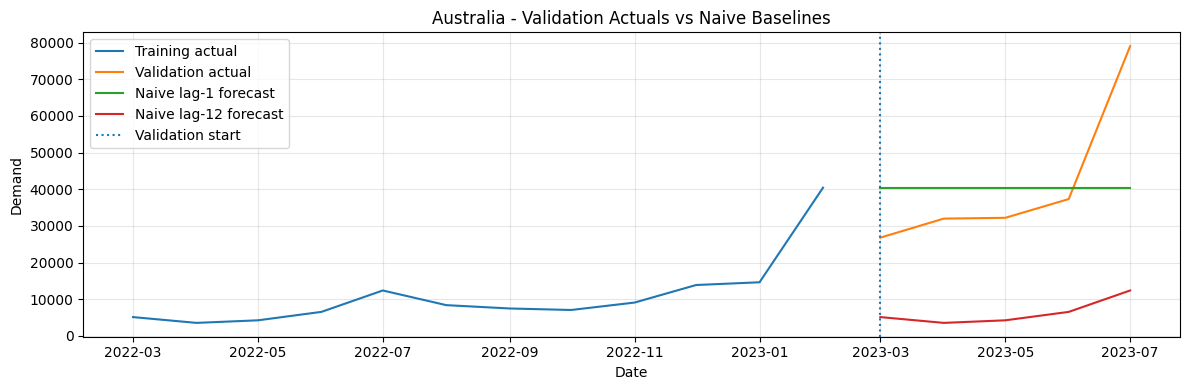

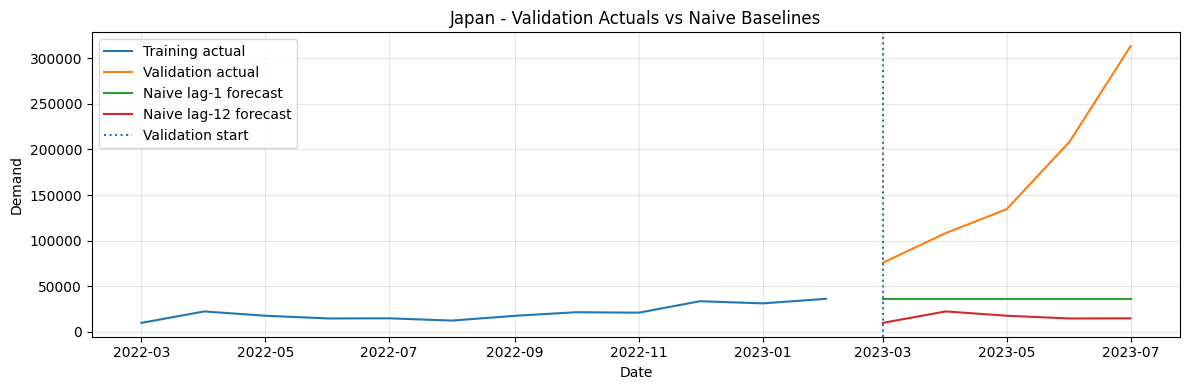

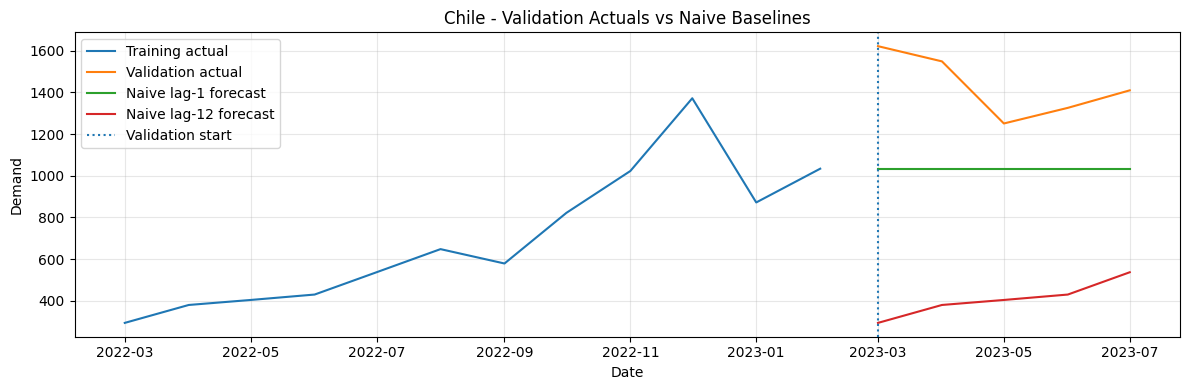

In [82]:
# Visualizing selected markets with actuals and baseline forecasts
selected_markets = ["Australia", "Japan", "Chile"]

for market in selected_markets:
    train_plot = training_actual_wide_to_2023M02[["Date", market]].copy()
    # Keeping the recent training period for clearer visualization
    train_plot = train_plot[
        train_plot["Date"].map(month_label_to_period)
        >= month_label_to_period("2022M03")
    ].copy()
    valid_actual_plot = validation_actual_wide_2023M03_2023M07[["Date", market]].copy()
    lag1_plot = baseline_lag1_validation_forecast_wide[["Date", market]].copy()
    lag12_plot = baseline_lag12_validation_forecast_wide[["Date", market]].copy()

    for df in [train_plot, valid_actual_plot, lag1_plot, lag12_plot]:
        df["_month_period"] = df["Date"].map(month_label_to_period)
        df["_month_date"] = df["_month_period"].dt.to_timestamp()

    plt.figure(figsize=(12, 4))
    plt.plot(train_plot["_month_date"], train_plot[market], label="Training actual")
    plt.plot(valid_actual_plot["_month_date"], valid_actual_plot[market], label="Validation actual")
    plt.plot(lag1_plot["_month_date"], lag1_plot[market], label="Naive lag-1 forecast")
    plt.plot(lag12_plot["_month_date"], lag12_plot[market], label="Naive lag-12 forecast")

    plt.title(f"{market} - Validation Actuals vs Naive Baselines")
    # Marking the start of the validation period
    plt.axvline(month_label_to_period("2023M03").to_timestamp(), linestyle=":", linewidth=1.5, label="Validation start")
    plt.xlabel("Date")
    plt.ylabel("Demand")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

#### Step 7 - Summary & Interpretation

The Part I integrated evidence confirms that the three functions developed in Q1–Q3 work together successfully on the full 20-destination validation dataset.

Both baseline forecasts passed the structural and alignment checks, and valid MAE, MASE and MAPE results were produced for every destination. Overall, the `naive_lag1` baseline performed better than `naive_lag12`, with a lower mean MASE (2.67 vs 4.41), median MASE (1.70 vs 3.83), and mean MAPE (48.06% vs 77.90%).

**The selected-market plots support this overall result**: For Australia, Japan and Chile, the lag-1 baseline generally remained closer to the validation actuals than the seasonal lag-12 baseline. However, both methods struggled when demand changed sharply during the validation period, particularly for Japan and the strong increase observed in Australia by July 2023.

These results provide the required baseline benchmark for Part II, where we will develop and evaluate improved forecasting approaches against the two naive baselines.

-----------------------------

## Part II: Forecasting project, evaluation, and interpretation

### Q4. Forecasting workflow and model development [20 marks]

Prepare cutoff-safe modelling inputs or model-ready evidence, compare `naive_lag1`, `naive_lag12`, and at least one improved method, select a final method, and produce `forecast_submission_wide`.

Required Q4 evidence: `tourism_series_long`, `modelling_data_or_feature_table`, `external_feature_log`, `validation_forecasts`, `validation_metrics`, `model_summary`, and `forecast_submission_wide`.

Minimum fixed contracts:

- `tourism_series_long`: DataFrame with `Date`, `destination`, `demand`.
- `external_feature_log`: DataFrame with `EXTERNAL_FEATURE_LOG_COLUMNS`; zero rows are valid only when no external data is used.
- `validation_forecasts`: DataFrame with `VALIDATION_FORECAST_COLUMNS`.
- `validation_metrics`: DataFrame with `VALIDATION_METRIC_COLUMNS`.
- `model_summary`: DataFrame with `MODEL_SUMMARY_COLUMNS`, covering the required models and exactly one `selected=True` row.

Additional useful columns are allowed. `modelling_data_or_feature_table` remains flexible so statistical and machine-learning methods are not forced into the same internal representation; it must still be inspectable and not remain `None`.

Validation must use `2023M03` to `2023M07`. Use MASE with naive lag-1 scaling and MAPE as required validation measures, with MAE available to support MASE numerator checking. Document leakage controls, external-data cutoff evidence, model-selection rationale, all-20 destination support, rerun steps, package assumptions, file paths, seeds or controlled stochastic behaviour, and final forecast stability checks.

**Required answer markers:** Do not delete, rename, edit, move, or reorder the Q4 START/END marker comments below. Write your response between them.

<!-- A2:ANSWER:Q4:START -->
Write your Q4 data preparation, modelling, validation, model-selection, reproducibility, and stability explanation here. Delete this sentence before submission.
<!-- A2:ANSWER:Q4:END -->

In [83]:
tourism_series_long = None  # TODO: DataFrame with at least Date, destination, demand.
modelling_data_or_feature_table = None  # TODO: inspectable cutoff-safe model-ready evidence.

# A zero-row table with these columns is valid only when no external data is used.
external_feature_log = pd.DataFrame(columns=EXTERNAL_FEATURE_LOG_COLUMNS)

validation_forecasts = None  # TODO: DataFrame with VALIDATION_FORECAST_COLUMNS.
validation_metrics = None  # TODO: DataFrame with VALIDATION_METRIC_COLUMNS.
model_summary = None  # TODO: DataFrame with MODEL_SUMMARY_COLUMNS and exactly one selected=True row.

### How we are breaking Part II down to keep things consistent:

#### Step 8 - Preparing Modelling Data
#### Step 9 - Developing Improved Forecasting Methods
#### Step 10 - Validating and Comparing Models
#### Step 11 - Selecting the Final Method and Retraining
#### Step 12 - Auditing and Exporting the Final Forecast
#### Step 13 - Interpreting Performance and Selected Markets

---------

### Step 8 - Preparing Modelling Data

#### 8.1 - Creating the Long-Format Tourism Series

In [84]:
# Creating the long-format tourism demand table
tourism_series_long = public_history_wide_to_2023M07.melt(
    id_vars="Date",
    value_vars=REQUIRED_DESTINATIONS,
    var_name="destination",
    value_name="demand",
)

# Adding a month-aware field for modelling and sorting
tourism_series_long["_month_period"] = (
    tourism_series_long["Date"].map(month_label_to_period)
)

tourism_series_long = (
    tourism_series_long
    .sort_values(["destination", "_month_period"])
    .reset_index(drop=True)
)

In [86]:
# Checking the long-format modelling data
print("Shape:", tourism_series_long.shape)
print("Destinations:", tourism_series_long["destination"].nunique())
print(
    "Period:",
    tourism_series_long["_month_period"].min(),
    "to",
    tourism_series_long["_month_period"].max(),
)

display(tourism_series_long.head())
display(tourism_series_long.tail())

Shape: (8300, 4)
Destinations: 20
Period: 1989-01 to 2023-07


,Date,destination,demand,_month_period
0,1989M01,Australia,1660.0,1989-01
1,1989M02,Australia,3090.0,1989-02
2,1989M03,Australia,2570.0,1989-03
3,1989M04,Australia,1580.0,1989-04
4,1989M05,Australia,1850.0,1989-05


,Date,destination,demand,_month_period
8295,2023M03,USA,67440.0,2023-03
8296,2023M04,USA,118631.0,2023-04
8297,2023M05,USA,87622.0,2023-05
8298,2023M06,USA,86392.0,2023-06
8299,2023M07,USA,110533.0,2023-07


#### 8.2 - Checking Modelling Data Completeness

In [87]:
# Checking the available modelling history for each destination
modelling_history_summary = (
    tourism_series_long
    .groupby("destination")
    .agg(
        first_available=(
            "Date",
            lambda x: x[
                tourism_series_long.loc[x.index, "demand"].notna()
            ].iloc[0]
        ),
        observations=("demand", "count"),
        missing_values=("demand", lambda x: x.isna().sum()),
    )
    .reset_index()
)

display(modelling_history_summary)

,destination,first_available,observations,missing_values
0,Australia,1989M01,415,0
1,Austria,2003M05,243,172
2,Cambodia,2003M01,247,168
3,Canada,2002M01,259,156
4,Chile,2012M01,124,291
5,Czech,2012M01,139,276
6,Hawaii,1989M01,415,0
7,Hong Kong China,1999M01,295,120
8,Indonesia,2013M01,127,288
9,Japan,1997M01,319,96


In [88]:
# Checking internal missing values after each destination starts
internal_missing_summary = []

for destination in REQUIRED_DESTINATIONS:
    market_data = tourism_series_long[
        tourism_series_long["destination"] == destination
    ].copy()

    first_valid_index = market_data["demand"].first_valid_index()

    if first_valid_index is not None:
        available_history = market_data.loc[first_valid_index:]

        internal_missing_summary.append({
            "destination": destination,
            "internal_missing_values": int(
                available_history["demand"].isna().sum()
            ),
        })

internal_missing_summary = pd.DataFrame(internal_missing_summary)

display(
    internal_missing_summary[
        internal_missing_summary["internal_missing_values"] > 0
    ]
)

,destination,internal_missing_values
1,Chile,15
8,Maldives,3
14,Thailand,6


#### 8.3 - Creating the Model-Ready Evidence Table

In [89]:
# Creating a cutoff-safe summary of the modelling history
modelling_data_or_feature_table = (
    tourism_series_long
    .groupby("destination")
    .agg(
        first_available=(
            "_month_period",
            lambda x: x[
                tourism_series_long.loc[x.index, "demand"].notna()
            ].min()
        ),
        last_available=(
            "_month_period",
            lambda x: x[
                tourism_series_long.loc[x.index, "demand"].notna()
            ].max()
        ),
        n_observations=("demand", "count"),
        n_missing=("demand", lambda x: x.isna().sum()),
    )
    .reset_index()
)

# Checking the model-ready evidence table
print("Shape:", modelling_data_or_feature_table.shape)
display(modelling_data_or_feature_table)

Shape: (20, 5)


,destination,first_available,last_available,n_observations,n_missing
0,Australia,1989-01,2023-07,415,0
1,Austria,2003-05,2023-07,243,172
2,Cambodia,2003-01,2023-07,247,168
3,Canada,2002-01,2023-07,259,156
4,Chile,2012-01,2023-07,124,291
5,Czech,2012-01,2023-07,139,276
6,Hawaii,1989-01,2023-07,415,0
7,Hong Kong China,1999-01,2023-07,295,120
8,Indonesia,2013-01,2023-07,127,288
9,Japan,1997-01,2023-07,319,96


**Note:** `n_missing` here includes all missing rows before a destination started, not only internal gaps. For example, Austria’s 172 missing values are mainly the months before 2003M05. That is expected. Our Step 8.2 check already showed that only Chile, Maldives, and Thailand have actual internal gaps after their series began.

#### 8.4 - Documenting External Data Usage

In [90]:
# Checking the external feature log
print("Shape:", external_feature_log.shape)
display(external_feature_log)

Shape: (0, 10)


,source_name,source_url_or_reference,local_file_or_url,retrieval_date,publication_or_release_date,latest_observation_used,cutoff_applicable,features_created,transformation_summary,licence_or_access_notes


This confirms that our modelling currently uses only the provided tourism-demand data; therefore, there are no external sources to document.

#### Step 8 - Summary & Findings

We prepared the modelling data required for Q4 using only information available up to the final public cutoff (`2023M07`).

The tourism dataset was converted to long format with one row per destination and month, covering all 20 destinations. We also created an inspectable modelling-history summary showing the available period, number of observations, and missing values for each destination.

The earlier checks confirmed that most missing values occur before individual destination series begin, while only Chile, Maldives, and Thailand contain internal historical gaps.

No external data is currently being used, so `external_feature_log` correctly remains an empty structured table with the required columns.

The modelling inputs are now ready for developing and validating improved forecasting methods.

--------------------

### Step 9 - Developing Improved Forecasting Methods

In this step, we are developing two improved forecasting approaches and comparing them later against the required naive baselines.

The first approach uses `Linear Regression` with engineered time-series features such as historical lags, moving averages, and calendar information. The second approach uses `SARIMA` to model temporal dependence and recurring seasonal patterns in the monthly tourism series.

Both approaches will be developed using only the historical tourism demand data available before the relevant forecasting cutoff, without using external or exogenous variables (*why we are mentioning this as we are aware that this is not a small textbook dataset, which definitely is affected multiple factors not visible in the data, to name one is the COVID epidemic in 2020 which definitely impacted arrivals and tourism around the world*)

#### Step 9.1 - Engineering Time-Series Features
#### Step 9.2 - Developing the Linear Regression Forecasting Model
#### Step 9.3 - Developing the SARIMA Forecasting Model
#### Step 9.4 - Generating Validation Forecasts

#### 9.1 - Engineering Time-Series Features

For the Linear Regression approach, we are converting the historical tourism series into supervised modelling data using lagged demand, recent moving averages, and cyclical month information.

All lag and rolling features are based only on previous observations. For validation modelling, the feature table is restricted to information available up to `2023M02`, preventing validation-period leakage.

In [91]:
# Building cutoff-safe regression features
def build_regression_feature_table(long_data, cutoff_label):
    feature_data = long_data.copy()

    # Keeping observations available up to the required cutoff
    cutoff_period = month_label_to_period(cutoff_label)
    feature_data = feature_data[
        feature_data["_month_period"] <= cutoff_period
    ].copy()

    # Sorting each destination chronologically
    feature_data = feature_data.sort_values(
        ["destination", "_month_period"]
    ).reset_index(drop=True)

    grouped = feature_data.groupby("destination")["demand"]

    # Creating historical lag features
    for lag in [1, 2, 3, 6, 12]:
        feature_data[f"lag_{lag}"] = grouped.shift(lag)

    # Creating moving averages using previous months only
    for window in [3, 6, 12]:
        feature_data[f"rolling_mean_{window}"] = (
            grouped.transform(
                lambda x: x.shift(1).rolling(
                    window=window,
                    min_periods=window
                ).mean()
            )
        )

    # Creating cyclical calendar features
    feature_data["month"] = feature_data["_month_period"].dt.month
    feature_data["month_sin"] = np.sin(
        2 * np.pi * feature_data["month"] / 12
    )
    feature_data["month_cos"] = np.cos(
        2 * np.pi * feature_data["month"] / 12
    )

    return feature_data

In [92]:
# Defining the regression predictor columns
REGRESSION_FEATURE_COLUMNS = [
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_6",
    "lag_12",
    "rolling_mean_3",
    "rolling_mean_6",
    "rolling_mean_12",
    "month_sin",
    "month_cos",
]

In [93]:
# Creating the validation-cutoff modelling feature table
modelling_data_or_feature_table = build_regression_feature_table(
    tourism_series_long,
    TRAIN_END,
)

# Keeping rows with complete predictors and target values
regression_training_data = modelling_data_or_feature_table.dropna(
    subset=["demand"] + REGRESSION_FEATURE_COLUMNS
).copy()

In [94]:
# Checking the engineered regression features
print("Feature table shape:", modelling_data_or_feature_table.shape)
print("Model-ready shape:", regression_training_data.shape)
print(
    "Destinations:",
    regression_training_data["destination"].nunique()
)
print(
    "Latest modelling month:",
    regression_training_data["_month_period"].max()
)

display(
    regression_training_data[
        [
            "Date",
            "destination",
            "demand",
            *REGRESSION_FEATURE_COLUMNS,
        ]
    ].tail()
)

Feature table shape: (8200, 15)
Model-ready shape: (4969, 15)
Destinations: 20
Latest modelling month: 2023-02


,Date,destination,demand,lag_1,lag_2,lag_3,lag_6,lag_12,rolling_mean_3,rolling_mean_6,rolling_mean_12,month_sin,month_cos
8195,2022M10,USA,32137.0,40169.0,75912.0,33041.0,14299.0,5910.0,49707.333333,35013.333333,24373.750000,-8.660254e-01,0.500000
8196,2022M11,USA,31651.0,32137.0,40169.0,75912.0,21237.0,10940.0,49406.000000,37986.333333,26559.333333,-5.000000e-01,0.866025
8197,2022M12,USA,48435.0,31651.0,32137.0,40169.0,25422.0,19747.0,34652.333333,39722.000000,28285.250000,-2.449294e-16,1.000000
8198,2023M01,USA,63386.0,48435.0,31651.0,32137.0,33041.0,20848.0,37407.666667,43557.500000,30675.916667,5.000000e-01,0.866025
8199,2023M02,USA,40829.0,63386.0,48435.0,31651.0,75912.0,8545.0,47824.000000,48615.000000,34220.750000,8.660254e-01,0.500000


#### 9.2 - Developing the Linear Regression Forecasting Model

We are fitting a separate Linear Regression model for each destination using the engineered lag, rolling-average, and cyclical month features. Validation forecasts are generated recursively from `2023M03` to `2023M07`, using only information available up to the `2023M02` cutoff and earlier generated forecasts when required.

In [95]:
# Loading the Linear Regression model
from sklearn.linear_model import LinearRegression

In [99]:
# Building recursive Linear Regression forecasts
def generate_linear_regression_forecast_wide(
    long_data,
    cutoff_label,
    forecast_months,
    required_destinations,
):
    forecast_rows = {
        month: {"Date": month}
        for month in forecast_months
    }

    fitted_models = {}

    for destination in required_destinations:

        # Using the model-ready features already created in Step 9.1
        training_data = regression_training_data[
            regression_training_data["destination"] == destination
        ].copy()

        X_train = training_data[REGRESSION_FEATURE_COLUMNS]
        y_train = training_data["demand"]

        # Fitting one model for the destination
        model = LinearRegression()
        model.fit(X_train, y_train)

        fitted_models[destination] = model

        # Creating working history using only data available at the cutoff
        cutoff_period = month_label_to_period(cutoff_label)

        destination_history = (
            long_data[
                (long_data["destination"] == destination)
                & (long_data["_month_period"] <= cutoff_period)
            ]
            .set_index("_month_period")["demand"]
            .copy()
        )

        # Forecasting each future month recursively
        for month in forecast_months:
            forecast_period = month_label_to_period(month)

            lag_1 = destination_history.get(forecast_period - 1, np.nan)
            lag_2 = destination_history.get(forecast_period - 2, np.nan)
            lag_3 = destination_history.get(forecast_period - 3, np.nan)
            lag_6 = destination_history.get(forecast_period - 6, np.nan)
            lag_12 = destination_history.get(forecast_period - 12, np.nan)

            previous_3 = [
                destination_history.get(forecast_period - lag, np.nan)
                for lag in range(1, 4)
            ]

            previous_6 = [
                destination_history.get(forecast_period - lag, np.nan)
                for lag in range(1, 7)
            ]

            previous_12 = [
                destination_history.get(forecast_period - lag, np.nan)
                for lag in range(1, 13)
            ]

            month_number = forecast_period.month

            feature_values = pd.DataFrame(
                [{
                    "lag_1": lag_1,
                    "lag_2": lag_2,
                    "lag_3": lag_3,
                    "lag_6": lag_6,
                    "lag_12": lag_12,
                    "rolling_mean_3": np.mean(previous_3),
                    "rolling_mean_6": np.mean(previous_6),
                    "rolling_mean_12": np.mean(previous_12),
                    "month_sin": np.sin(
                        2 * np.pi * month_number / 12
                    ),
                    "month_cos": np.cos(
                        2 * np.pi * month_number / 12
                    ),
                }]
            )

            forecast_value = float(
                model.predict(feature_values)[0]
            )

            # Preventing impossible negative tourism demand
            forecast_value = max(0.0, forecast_value)

            forecast_rows[month][destination] = forecast_value

            # Adding the generated forecast to history for the next month
            destination_history.loc[forecast_period] = forecast_value

    forecast_wide = pd.DataFrame(
        [forecast_rows[month] for month in forecast_months],
        columns=["Date"] + list(required_destinations),
    )

    return forecast_wide, fitted_models

In [100]:
# Generating Linear Regression validation forecasts
linear_regression_validation_forecast_wide, linear_regression_models = (
    generate_linear_regression_forecast_wide(
        long_data=tourism_series_long,
        cutoff_label=TRAIN_END,
        forecast_months=VALIDATION_MONTHS,
        required_destinations=REQUIRED_DESTINATIONS,
    )
)

In [101]:
# Checking the Linear Regression validation forecasts
print(
    "Shape:",
    linear_regression_validation_forecast_wide.shape
)

print(
    "Models fitted:",
    len(linear_regression_models)
)

display(
    linear_regression_validation_forecast_wide[
        ["Date", "Australia", "Japan", "Chile"]
    ]
)

Shape: (5, 21)
Models fitted: 20


,Date,Australia,Japan,Chile
0,2023M03,19434.711916,42959.346035,1062.093173
1,2023M04,12157.533625,59872.132400,889.652333
2,2023M05,6973.765794,78439.884828,748.239801
3,2023M06,8510.641638,93339.481307,646.814061
4,2023M07,12685.517315,101615.031688,784.703007


In [102]:
# Evaluating the Linear Regression validation forecasts
linear_regression_destination_metrics, linear_regression_aggregate_metrics = (
    evaluate_forecast_wide(
        forecast_wide_df=linear_regression_validation_forecast_wide,
        actual_wide_df=validation_actual_wide_2023M03_2023M07,
        training_actual_wide_df=training_actual_wide_to_2023M02,
        start_month=VALIDATION_START,
        end_month=VALIDATION_END,
        required_destinations=REQUIRED_DESTINATIONS,
        naive_lag=1,
        date_column="Date",
    )
)

print("Linear Regression aggregate metrics:")
print(linear_regression_aggregate_metrics)

display(
    linear_regression_destination_metrics[
        linear_regression_destination_metrics["destination"].isin(
            ["Australia", "Japan", "Chile"]
        )
    ]
)

Linear Regression aggregate metrics:
{'n_destinations': 20, 'mean_mase': np.float64(2.6377223782920973), 'median_mase': np.float64(2.2596292158655875), 'mean_mape': np.float64(45.39941807602714)}


,destination,n,mae,mase,mape,denominator,n_denominator_pairs,mase_available,denominator_warning
1,Chile,5,605.299525,2.125934,42.568437,284.721739,115,True,False
5,Japan,5,92836.024748,3.345991,50.493351,27745.450479,313,True,False
16,Australia,5,29525.565942,3.419643,65.803671,8634.107579,409,True,False


##### Linear Regression - Initial Validation Comparison

Linear Regression produced a mean MASE of **2.64** and mean MAPE of **45.40%**, slightly improving on `naive_lag1` (**2.67 MASE**, **48.06% MAPE**) and clearly outperforming `naive_lag12` (**4.41 MASE**, **77.90% MAPE**).

However, its median MASE (**2.26**) was higher than the lag-1 baseline (**1.70**), suggesting that the improvement was not consistent across all destinations. Overall, Linear Regression shows some improvement at the aggregate level, but destination-level performance remains mixed.

#### 9.3 - Developing the SARIMA Forecasting Model

We are developing a separate SARIMA model for each destination using its historical monthly demand series. Unlike Linear Regression, SARIMA works directly with the time-series sequence and models both recent temporal dependence and annual seasonality.

For each destination, several small SARIMA specifications are fitted using only data available up to `2023M02`. The specification with the lowest training AIC is selected, and five validation-month forecasts are generated for `2023M03` to `2023M07`.

In [103]:
# Loading the SARIMA model
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings

In [109]:
# Defining a small set of SARIMA specifications
SARIMA_CANDIDATES = [
    ((1, 1, 0), (1, 0, 0, 12)),
    ((0, 1, 1), (0, 0, 1, 12)),
    ((1, 1, 1), (1, 0, 1, 12)),
    ((1, 0, 1), (1, 1, 0, 12)),
    ((1, 0, 1), (0, 1, 1, 12)),
    ((1, 1, 1), (0, 1, 1, 12)),
]

In [110]:
# Building destination-level SARIMA forecasts
def generate_sarima_forecast_wide(
    long_data,
    cutoff_label,
    forecast_months,
    required_destinations,
):
    cutoff_period = month_label_to_period(cutoff_label)

    forecast_rows = {
        month: {"Date": month}
        for month in forecast_months
    }

    model_details = []

    for destination in required_destinations:

        # Preparing the historical series up to the cutoff
        destination_series = (
            long_data[
                (long_data["destination"] == destination)
                & (long_data["_month_period"] <= cutoff_period)
            ]
            .sort_values("_month_period")
            .set_index("_month_period")["demand"]
            .astype(float)
        )

        # Removing only leading missing periods before the series starts
        first_valid_period = destination_series.first_valid_index()
        destination_series = destination_series.loc[first_valid_period:]

        best_result = None
        best_order = None
        best_seasonal_order = None
        best_aic = np.inf

        # Testing the candidate SARIMA specifications
        for order, seasonal_order in SARIMA_CANDIDATES:

            try:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")

                    model = SARIMAX(
                        destination_series,
                        order=order,
                        seasonal_order=seasonal_order,
                        enforce_stationarity=False,
                        enforce_invertibility=False,
                    )

                    result = model.fit(disp=False)

                if np.isfinite(result.aic) and result.aic < best_aic:
                    best_result = result
                    best_order = order
                    best_seasonal_order = seasonal_order
                    best_aic = result.aic

            except Exception:
                continue

        if best_result is None:
            raise ValueError(
                f"No SARIMA model could be fitted for {destination}"
            )

        # Generating the validation forecasts
        forecasts = best_result.forecast(
            steps=len(forecast_months)
        )

        forecasts = np.asarray(forecasts, dtype=float)

        # Preventing impossible negative tourism demand
        forecasts = np.maximum(forecasts, 0.0)

        for month, forecast_value in zip(
            forecast_months,
            forecasts,
        ):
            forecast_rows[month][destination] = float(
                forecast_value
            )

        model_details.append({
            "destination": destination,
            "order": best_order,
            "seasonal_order": best_seasonal_order,
            "aic": best_aic,
        })

    forecast_wide = pd.DataFrame(
        [forecast_rows[month] for month in forecast_months],
        columns=["Date"] + list(required_destinations),
    )

    model_details = pd.DataFrame(model_details)

    return forecast_wide, model_details

In [111]:
# Generating SARIMA validation forecasts
sarima_validation_forecast_wide, sarima_model_details = (
    generate_sarima_forecast_wide(
        long_data=tourism_series_long,
        cutoff_label=TRAIN_END,
        forecast_months=VALIDATION_MONTHS,
        required_destinations=REQUIRED_DESTINATIONS,
    )
)

In [112]:
# Checking the SARIMA validation forecasts
print("Shape:", sarima_validation_forecast_wide.shape)
print("Models fitted:", len(sarima_model_details))

display(
    sarima_validation_forecast_wide[
        ["Date", "Australia", "Japan", "Chile"]
    ]
)

display(sarima_model_details)

Shape: (5, 21)
Models fitted: 20


,Date,Australia,Japan,Chile
0,2023M03,5693.653180,13473.026156,1063.313885
1,2023M04,0.000000,33617.674532,850.335659
2,2023M05,0.000000,25173.579621,570.133394
3,2023M06,0.000000,57373.160406,287.563675
4,2023M07,12544.606562,119926.162218,285.527460


,destination,order,seasonal_order,aic
0,Canada,"(1, 1, 1)","(0, 1, 1, 12)",4666.137087
1,Chile,"(1, 1, 1)","(0, 1, 1, 12)",1382.670526
2,Mexico,"(1, 1, 1)","(0, 1, 1, 12)",3444.792041
3,Taiwan China,"(1, 1, 1)","(0, 1, 1, 12)",3550.156503
4,Hong Kong China,"(1, 1, 1)","(0, 1, 1, 12)",7407.607954
5,Japan,"(1, 1, 1)","(0, 1, 1, 12)",7199.863309
6,South Korea,"(1, 1, 1)","(0, 1, 1, 12)",6788.581265
7,Macao China,"(1, 1, 1)","(0, 1, 1, 12)",7192.158290
8,Maldives,"(1, 1, 1)","(0, 1, 1, 12)",5279.570859
9,Cambodia,"(1, 1, 1)","(0, 1, 1, 12)",4650.226963


##### SARIMA Forecast Behaviour

The SARIMA forecasts produced some negative raw predictions for Australia during the validation horizon. Since tourism demand cannot be negative, these values were constrained to zero before evaluation.

This behaviour indicates that the selected SARIMA specification was not fully stable for Australia during this period. In particular, the recent demand pattern was changing substantially, while SARIMA relied on historical autoregressive and seasonal relationships. The zero values therefore represent a modelling limitation rather than observed or assumed zero tourism demand.

In [113]:
# Evaluating the SARIMA validation forecasts
sarima_destination_metrics, sarima_aggregate_metrics = (
    evaluate_forecast_wide(
        forecast_wide_df=sarima_validation_forecast_wide,
        actual_wide_df=validation_actual_wide_2023M03_2023M07,
        training_actual_wide_df=training_actual_wide_to_2023M02,
        start_month=VALIDATION_START,
        end_month=VALIDATION_END,
        required_destinations=REQUIRED_DESTINATIONS,
        naive_lag=1,
        date_column="Date",
    )
)

print("SARIMA aggregate metrics:")
print(sarima_aggregate_metrics)

display(
    sarima_destination_metrics[
        sarima_destination_metrics["destination"].isin(
            ["Australia", "Japan", "Chile"]
        )
    ]
)

SARIMA aggregate metrics:
{'n_destinations': 20, 'mean_mase': np.float64(3.0991762189743155), 'median_mase': np.float64(2.8489514885469305), 'mean_mape': np.float64(60.31426084059808)}


,destination,n,mae,mase,mape,denominator,n_denominator_pairs,mase_available,denominator_warning
1,Chile,5,820.225186,2.880796,58.407511,284.721739,115,True,False
5,Japan,5,118168.479414,4.259022,73.332388,27745.450479,313,True,False
16,Australia,5,37830.348052,4.381501,92.578347,8634.107579,409,True,False


##### SARIMA - Initial Validation Comparison

After testing a broader controlled set of SARIMA specifications, SARIMA achieved a mean MASE of **3.10**, median MASE of **2.85**, and mean MAPE of **60.31%** across the 20 destinations.

This remained weaker than Linear Regression (**2.64 mean MASE**, **45.40% mean MAPE**) and the `naive_lag1` baseline (**2.67 mean MASE**, **48.06% mean MAPE**), although it still performed better than `naive_lag12` (**4.41 mean MASE**, **77.90% mean MAPE**).

The broader SARIMA candidate search therefore did not improve aggregate validation performance. This suggests that the historical autoregressive and seasonal patterns captured by SARIMA were less effective during the rapidly changing post-cutoff demand period than the relationships captured by Linear Regression or the recent-value lag-1 baseline.

#### 9.4 - Consolidating Validation Forecasts and Metrics

We are combining the validation forecasts and destination-level performance measures from the two required naive baselines, Linear Regression, and SARIMA into the standard Q4 evidence tables. This allows all four approaches to be compared consistently in the next step.

In [114]:
# Converting wide forecast tables to the required long format
def forecast_wide_to_long(forecast_wide, model_label):
    forecast_long = forecast_wide.melt(
        id_vars="Date",
        value_vars=REQUIRED_DESTINATIONS,
        var_name="destination",
        value_name="forecast",
    )

    forecast_long.insert(0, "model_label", model_label)

    return forecast_long[VALIDATION_FORECAST_COLUMNS]

In [115]:
# Consolidating validation forecasts from all models
validation_forecasts = pd.concat(
    [
        forecast_wide_to_long(
            baseline_lag1_validation_forecast_wide,
            "naive_lag1",
        ),
        forecast_wide_to_long(
            baseline_lag12_validation_forecast_wide,
            "naive_lag12",
        ),
        forecast_wide_to_long(
            linear_regression_validation_forecast_wide,
            "linear_regression",
        ),
        forecast_wide_to_long(
            sarima_validation_forecast_wide,
            "sarima",
        ),
    ],
    ignore_index=True,
)

In [116]:
# Adding model labels to the destination-level metrics
lag1_metrics = lag1_destination_metrics.copy()
lag1_metrics.insert(0, "model_label", "naive_lag1")

lag12_metrics = lag12_destination_metrics.copy()
lag12_metrics.insert(0, "model_label", "naive_lag12")

linear_regression_metrics = linear_regression_destination_metrics.copy()
linear_regression_metrics.insert(0, "model_label", "linear_regression")

sarima_metrics = sarima_destination_metrics.copy()
sarima_metrics.insert(0, "model_label", "sarima")

# Consolidating validation metrics from all models
validation_metrics = pd.concat(
    [
        lag1_metrics,
        lag12_metrics,
        linear_regression_metrics,
        sarima_metrics,
    ],
    ignore_index=True,
)[VALIDATION_METRIC_COLUMNS]

In [117]:
# Checking the consolidated validation evidence
print("Validation forecasts shape:", validation_forecasts.shape)
print("Validation metrics shape:", validation_metrics.shape)

print("\nForecast rows by model:")
print(validation_forecasts["model_label"].value_counts())

print("\nMetric rows by model:")
print(validation_metrics["model_label"].value_counts())

display(validation_forecasts.head())
display(validation_metrics.head())

Validation forecasts shape: (400, 4)
Validation metrics shape: (80, 10)

Forecast rows by model:
model_label
naive_lag1           100
naive_lag12          100
linear_regression    100
sarima               100
Name: count, dtype: int64

Metric rows by model:
model_label
naive_lag1           20
naive_lag12          20
linear_regression    20
sarima               20
Name: count, dtype: int64


,model_label,Date,destination,forecast
0,naive_lag1,2023M03,Canada,8132.0
1,naive_lag1,2023M04,Canada,8132.0
2,naive_lag1,2023M05,Canada,8132.0
3,naive_lag1,2023M06,Canada,8132.0
4,naive_lag1,2023M07,Canada,8132.0


,model_label,destination,n,mae,mase,mape,denominator,n_denominator_pairs,mase_available,denominator_warning
0,naive_lag1,Canada,5,8453.4,1.353923,44.825228,6243.636364,253,True,False
1,naive_lag1,Chile,5,397.6,1.396451,27.106541,284.721739,115,True,False
2,naive_lag1,Mexico,5,2637.8,1.654912,21.466003,1593.921659,217,True,False
3,naive_lag1,Taiwan China,5,6878.6,0.280336,37.065578,24537.011429,175,True,False
4,naive_lag1,Hong Kong China,5,1229352.2,5.208431,51.651148,236031.183391,289,True,False


#### Step 9 - Summary & Findings

We developed and validated two improved forecasting approaches: Linear Regression with engineered lag, rolling-average, and seasonal features, and SARIMA using destination-specific monthly time-series models.

Both methods produced validation forecasts for all 20 destinations over `2023M03` to `2023M07`. Linear Regression achieved stronger aggregate validation performance than SARIMA and slightly improved on the lag-1 baseline in mean MASE and mean MAPE, while SARIMA remained weaker during this validation period.

The forecasts and destination-level validation measures from all four approaches — `naive_lag1`, `naive_lag12`, `linear_regression`, and `sarima` — were consolidated into the required `validation_forecasts` and `validation_metrics` objects.

These results are now ready for formal model comparison and final model selection.

-------------------------

### Step 10 - Validating and Comparing Models

#### Step 10.1 - Comparing Aggregate Validation Performance
#### Step 10.2 - Reviewing Destination-Level Performance
#### Step 10.3 - Creating the Model Summary and Selecting the Final Method
#### Step 10.4 - Visualizing Selected Market Model Performance

#### 10.1 - Comparing Aggregate Validation Performance

In [118]:
# Summarizing validation performance across all destinations
model_validation_summary = (
    validation_metrics
    .groupby("model_label")
    .agg(
        n_destinations=("destination", "nunique"),
        mean_mase=("mase", "mean"),
        median_mase=("mase", "median"),
        mean_mape=("mape", "mean"),
    )
    .reset_index()
    .sort_values("mean_mase")
    .reset_index(drop=True)
)

display(model_validation_summary)

,model_label,n_destinations,mean_mase,median_mase,mean_mape
0,linear_regression,20,2.637722,2.259629,45.399418
1,naive_lag1,20,2.670678,1.696372,48.057645
2,sarima,20,3.099176,2.848951,60.314261
3,naive_lag12,20,4.409591,3.828656,77.898728


#### 10.2 - Reviewing Destination-Level Performance

In [119]:
# Comparing destination-level MASE across the four models
destination_model_comparison = (
    validation_metrics
    .pivot(
        index="destination",
        columns="model_label",
        values="mase",
    )
    .reset_index()
)

model_columns = [
    "naive_lag1",
    "naive_lag12",
    "linear_regression",
    "sarima",
]

destination_model_comparison["best_model"] = (
    destination_model_comparison[model_columns]
    .idxmin(axis=1)
)

print("Best model count by destination:")
print(
    destination_model_comparison["best_model"]
    .value_counts()
)

display(destination_model_comparison)

Best model count by destination:
best_model
naive_lag1           9
linear_regression    6
sarima               4
naive_lag12          1
Name: count, dtype: int64


model_label,destination,linear_regression,naive_lag1,naive_lag12,sarima,best_model
0,Australia,3.419643,1.667341,4.065736,4.381501,naive_lag1
1,Austria,0.213438,1.578013,1.801027,0.958738,linear_regression
2,Cambodia,0.921492,1.097318,6.709391,0.908829,sarima
3,Canada,0.348357,1.353923,1.933521,1.363263,linear_regression
4,Chile,2.125934,1.396451,3.591577,2.880796,naive_lag1
5,Czech,1.010833,1.114481,1.142143,0.847650,sarima
6,Hawaii,0.200421,0.558009,0.176652,0.803048,naive_lag12
7,Hong Kong China,6.958699,5.208431,9.830690,7.093745,naive_lag1
8,Indonesia,1.172589,1.725403,3.463357,2.323492,linear_regression
9,Japan,3.345991,4.753255,5.486543,4.259022,linear_regression


##### Model Comparison Observations

The validation results show a mixed destination-level picture. Linear Regression achieved the lowest overall mean MASE (**2.64**) and mean MAPE (**45.40%**), slightly improving on the `naive_lag1` baseline (**2.67 mean MASE** and **48.06% mean MAPE**).

However, `naive_lag1` achieved the lower median MASE (**1.70** compared with **2.26**) and was the lowest-MASE method for **9 of the 20 destinations**, compared with **6** for Linear Regression. SARIMA performed best for four destinations and `naive_lag12` for one.

This indicates that no single method dominated every destination. Linear Regression provided the strongest aggregate performance, while the lag-1 baseline remained highly competitive at the individual-destination level.

#### Step 10.3 - Creating the Model Summary and Selecting the Final Method

The validation results showed that no individual forecasting method performed best across all destinations. Although Linear Regression achieved the strongest aggregate mean MASE and mean MAPE, the destination-level comparison showed that different markets favoured different models.

We might therefore select a `destination-specific` hybrid strategy. For each destination, the forecasting method with the lowest validation MASE is selected. This allows the final forecasting workflow to retain the model that performed best for each individual market while using the same cutoff-safe validation evidence.

Because the model choice is based on a five-month validation period, the destination-specific selections may be sensitive to this relatively short validation window. This limitation will be considered when interpreting the final forecasts.

In [123]:
# Creating the destination-specific best-model mapping
best_model_by_destination = (
    destination_model_comparison
    .set_index("destination")["best_model"]
    .to_dict()
)

# Collecting the validation metrics for each destination's selected model
hybrid_metric_rows = []

for destination, selected_model in best_model_by_destination.items():
    selected_row = validation_metrics[
        (validation_metrics["destination"] == destination)
        & (validation_metrics["model_label"] == selected_model)
    ].copy()

    selected_row["model_label"] = "hybrid_destination_best"
    hybrid_metric_rows.append(selected_row)

hybrid_validation_metrics = pd.concat(
    hybrid_metric_rows,
    ignore_index=True,
)[VALIDATION_METRIC_COLUMNS]

# Calculating aggregate validation measures for the hybrid approach
hybrid_summary = {
    "n_destinations": hybrid_validation_metrics["destination"].nunique(),
    "mean_mase": hybrid_validation_metrics["mase"].mean(),
    "median_mase": hybrid_validation_metrics["mase"].median(),
    "mean_mape": hybrid_validation_metrics["mape"].mean(),
}

In [124]:
# Creating the final model summary
model_summary = pd.DataFrame(
    [
        {
            "model_label": "naive_lag1",
            "model_family": "Naive baseline",
            "n_destinations": int(
                summary_lookup.loc["naive_lag1", "n_destinations"]
            ),
            "mean_mase": float(
                summary_lookup.loc["naive_lag1", "mean_mase"]
            ),
            "median_mase": float(
                summary_lookup.loc["naive_lag1", "median_mase"]
            ),
            "mean_mape": float(
                summary_lookup.loc["naive_lag1", "mean_mape"]
            ),
            "selected": False,
            "selection_rationale": (
                "Strong destination-level baseline but not selected "
                "as the single final strategy."
            ),
            "reproducibility_notes": (
                "Deterministic lag-1 forecasting using historical demand."
            ),
            "stability_notes": (
                "Stable and deterministic across reruns."
            ),
        },
        {
            "model_label": "naive_lag12",
            "model_family": "Seasonal naive baseline",
            "n_destinations": int(
                summary_lookup.loc["naive_lag12", "n_destinations"]
            ),
            "mean_mase": float(
                summary_lookup.loc["naive_lag12", "mean_mase"]
            ),
            "median_mase": float(
                summary_lookup.loc["naive_lag12", "median_mase"]
            ),
            "mean_mape": float(
                summary_lookup.loc["naive_lag12", "mean_mape"]
            ),
            "selected": False,
            "selection_rationale": (
                "Useful seasonal baseline but weaker overall validation performance."
            ),
            "reproducibility_notes": (
                "Deterministic lag-12 forecasting using historical demand."
            ),
            "stability_notes": (
                "Stable and deterministic across reruns."
            ),
        },
        {
            "model_label": "linear_regression",
            "model_family": "Linear Regression",
            "n_destinations": int(
                summary_lookup.loc["linear_regression", "n_destinations"]
            ),
            "mean_mase": float(
                summary_lookup.loc["linear_regression", "mean_mase"]
            ),
            "median_mase": float(
                summary_lookup.loc["linear_regression", "median_mase"]
            ),
            "mean_mape": float(
                summary_lookup.loc["linear_regression", "mean_mape"]
            ),
            "selected": False,
            "selection_rationale": (
                "Strongest aggregate individual model, but not best "
                "for every destination."
            ),
            "reproducibility_notes": (
                "Uses fixed lag, rolling-average, and calendar features "
                "with deterministic destination-level Linear Regression."
            ),
            "stability_notes": (
                "Deterministic with the same cutoff and feature process."
            ),
        },
        {
            "model_label": "sarima",
            "model_family": "SARIMA",
            "n_destinations": int(
                summary_lookup.loc["sarima", "n_destinations"]
            ),
            "mean_mase": float(
                summary_lookup.loc["sarima", "mean_mase"]
            ),
            "median_mase": float(
                summary_lookup.loc["sarima", "median_mase"]
            ),
            "mean_mape": float(
                summary_lookup.loc["sarima", "mean_mape"]
            ),
            "selected": False,
            "selection_rationale": (
                "Best for some destinations but weaker at the aggregate level."
            ),
            "reproducibility_notes": (
                "Uses a fixed SARIMA candidate set with AIC-based "
                "destination-level model selection."
            ),
            "stability_notes": (
                "Some destination forecasts showed instability."
            ),
        },
        {
            "model_label": "hybrid_destination_best",
            "model_family": "Destination-specific hybrid",
            "n_destinations": int(
                hybrid_summary["n_destinations"]
            ),
            "mean_mase": float(
                hybrid_summary["mean_mase"]
            ),
            "median_mase": float(
                hybrid_summary["median_mase"]
            ),
            "mean_mape": float(
                hybrid_summary["mean_mape"]
            ),
            "selected": True,
            "selection_rationale": (
                "Selected because each destination uses the model with "
                "the lowest validation MASE."
            ),
            "reproducibility_notes": (
                "Uses a fixed destination-to-model mapping derived from "
                "the common validation period."
            ),
            "stability_notes": (
                "Deterministic once the mapping is fixed, although model "
                "selection is based on a five-month validation window."
            ),
        },
    ],
    columns=MODEL_SUMMARY_COLUMNS,
)

# Checking that exactly one final strategy is selected
print("Selected models:", model_summary["selected"].sum())
display(model_summary)

Selected models: 1


,model_label,model_family,n_destinations,mean_mase,median_mase,mean_mape,selected,selection_rationale,reproducibility_notes,stability_notes
0,naive_lag1,Naive baseline,20,2.670678,1.696372,48.057645,False,Strong destination-level baseline but not sele...,Deterministic lag-1 forecasting using historic...,Stable and deterministic across reruns.
1,naive_lag12,Seasonal naive baseline,20,4.409591,3.828656,77.898728,False,Useful seasonal baseline but weaker overall va...,Deterministic lag-12 forecasting using histori...,Stable and deterministic across reruns.
2,linear_regression,Linear Regression,20,2.637722,2.259629,45.399418,False,"Strongest aggregate individual model, but not ...","Uses fixed lag, rolling-average, and calendar ...",Deterministic with the same cutoff and feature...
3,sarima,SARIMA,20,3.099176,2.848951,60.314261,False,Best for some destinations but weaker at the a...,Uses a fixed SARIMA candidate set with AIC-bas...,Some destination forecasts showed instability.
4,hybrid_destination_best,Destination-specific hybrid,20,2.166459,1.565277,35.801040,True,Selected because each destination uses the mod...,Uses a fixed destination-to-model mapping deri...,"Deterministic once the mapping is fixed, altho..."


#### 10.4 - Visualizing Selected Market Model Performance

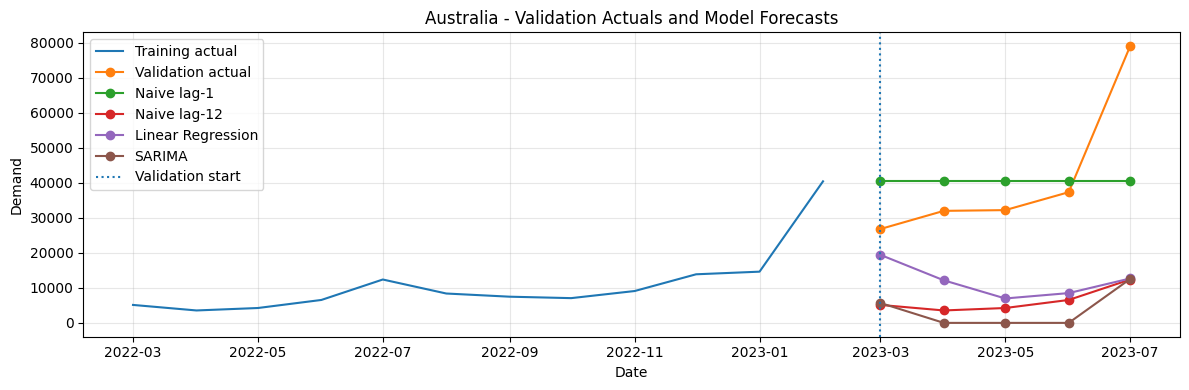

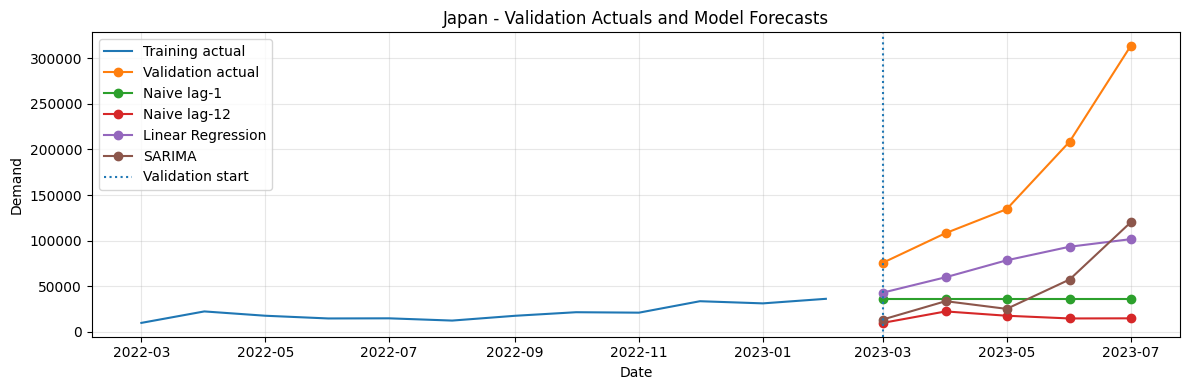

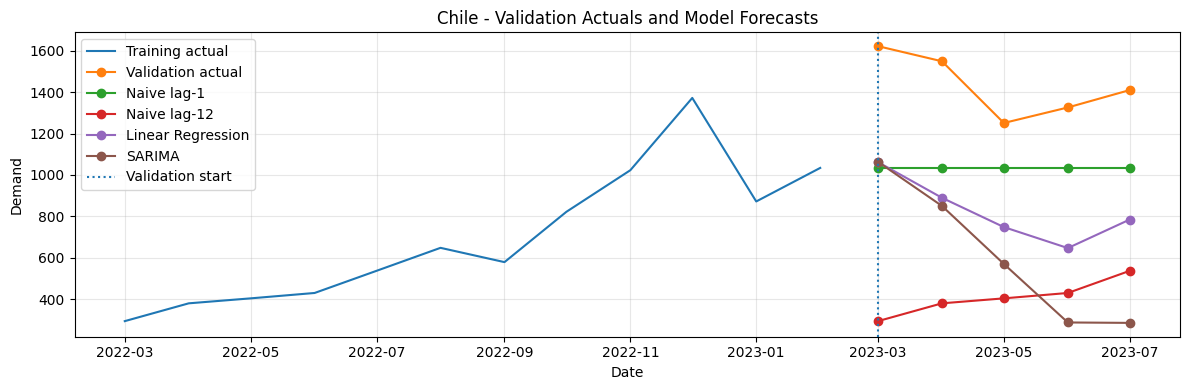

In [122]:
# Visualizing validation performance for selected markets
selected_markets = ["Australia", "Japan", "Chile"]

for market in selected_markets:

    # Preparing recent training history for clearer visualization
    train_plot = training_actual_wide_to_2023M02[
        ["Date", market]
    ].copy()

    train_plot = train_plot[
        train_plot["Date"].map(month_label_to_period)
        >= month_label_to_period("2022M03")
    ].copy()

    # Preparing validation actuals and forecasts
    actual_plot = validation_actual_wide_2023M03_2023M07[
        ["Date", market]
    ].copy()

    lag1_plot = baseline_lag1_validation_forecast_wide[
        ["Date", market]
    ].copy()

    lag12_plot = baseline_lag12_validation_forecast_wide[
        ["Date", market]
    ].copy()

    regression_plot = linear_regression_validation_forecast_wide[
        ["Date", market]
    ].copy()

    sarima_plot = sarima_validation_forecast_wide[
        ["Date", market]
    ].copy()

    # Converting month labels for plotting
    for df in [
        train_plot,
        actual_plot,
        lag1_plot,
        lag12_plot,
        regression_plot,
        sarima_plot,
    ]:
        df["_month_date"] = (
            df["Date"]
            .map(month_label_to_period)
            .dt.to_timestamp()
        )

    # Plotting the validation comparison
    plt.figure(figsize=(12, 4))

    plt.plot(
        train_plot["_month_date"],
        train_plot[market],
        label="Training actual",
    )

    plt.plot(
        actual_plot["_month_date"],
        actual_plot[market],
        marker="o",
        label="Validation actual",
    )

    plt.plot(
        lag1_plot["_month_date"],
        lag1_plot[market],
        marker="o",
        label="Naive lag-1",
    )

    plt.plot(
        lag12_plot["_month_date"],
        lag12_plot[market],
        marker="o",
        label="Naive lag-12",
    )

    plt.plot(
        regression_plot["_month_date"],
        regression_plot[market],
        marker="o",
        label="Linear Regression",
    )

    plt.plot(
        sarima_plot["_month_date"],
        sarima_plot[market],
        marker="o",
        label="SARIMA",
    )

    # Marking the beginning of the validation period
    plt.axvline(
        month_label_to_period("2023M03").to_timestamp(),
        linestyle=":",
        linewidth=1.5,
        label="Validation start",
    )

    plt.title(
        f"{market} - Validation Actuals and Model Forecasts"
    )
    plt.xlabel("Date")
    plt.ylabel("Demand")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

#### Step 10 - Summary & Findings

The four forecasting approaches showed different strengths across the 20 destinations. Linear Regression achieved the strongest aggregate validation performance, with the lowest mean MASE (**2.64**) and mean MAPE (**45.40%**), while `naive_lag1` achieved the lowest median MASE (**1.70**) and the best destination-level MASE for **9 of the 20 markets**.

The destination-level comparison showed that `naive_lag1` performed best for 9 destinations, Linear Regression for 6, SARIMA for 4, and `naive_lag12` for 1. The selected-market plots also demonstrate that different destinations can favour different forecasting approaches.

--> For example, based on the visuals above and the summary table (destination_model_comparison) showing each market's best model in step 10.2,  `naive_lag1` provided the strongest validation performance for Australia, while Linear Regression followed Japan's rapidly increasing demand more closely.

These results suggest that applying one forecasting model to all destinations may not provide the strongest overall solution. Therefore, rather than selecting Linear Regression for every market, we will proceed with a **destination-specific hybrid forecasting approach** as already specified in section 10.3 above, where the model with the lowest validation MASE is selected separately for each destination.

This approach retains the same cutoff-safe validation framework while allowing each destination to use the forecasting method that performed best on its own validation evidence. The final selected method will therefore be treated as a single hybrid forecasting strategy composed of destination-specific model selections.

----------------

### Step 11 - Building the Final Hybrid Forecast

#### 11.1 - Preparing the Final-Cutoff Model Inputs

In [126]:
# Rebuilding the regression features using the final public cutoff
final_regression_feature_table = build_regression_feature_table(
    tourism_series_long,
    "2023M07",
)

final_regression_training_data = final_regression_feature_table.dropna(
    subset=["demand"] + REGRESSION_FEATURE_COLUMNS
).copy()

# Checking the final-cutoff regression training data
print("Shape:", final_regression_training_data.shape)
print(
    "Latest modelling month:",
    final_regression_training_data["_month_period"].max()
)
print(
    "Destinations:",
    final_regression_training_data["destination"].nunique()
)

Shape: (5069, 15)
Latest modelling month: 2023-07
Destinations: 20


#### 11.2 - Generating the Final 12-Month Hybrid Forecast

**The Naive Forecasts**

In [127]:
# Generating the final naive baseline forecasts
final_lag1_forecast_wide = generate_naive_forecast_wide(
    historical_actual_wide=public_history_wide_to_2023M07,
    cutoff_label="2023M07",
    forecast_months=FINAL_FORECAST_MONTHS,
    required_destinations=REQUIRED_DESTINATIONS,
    lag=1,
    date_column="Date",
)

final_lag12_forecast_wide = generate_naive_forecast_wide(
    historical_actual_wide=public_history_wide_to_2023M07,
    cutoff_label="2023M07",
    forecast_months=FINAL_FORECAST_MONTHS,
    required_destinations=REQUIRED_DESTINATIONS,
    lag=12,
    date_column="Date",
)

**The Linear Regression**

In [128]:
# Building final recursive Linear Regression forecasts
def generate_final_linear_regression_forecast(
    long_data,
    training_data,
    cutoff_label,
    forecast_months,
    required_destinations,
):
    forecast_rows = {
        month: {"Date": month}
        for month in forecast_months
    }

    cutoff_period = month_label_to_period(cutoff_label)

    for destination in required_destinations:

        # Fitting the destination-level model
        destination_training = training_data[
            training_data["destination"] == destination
        ].copy()

        X_train = destination_training[REGRESSION_FEATURE_COLUMNS]
        y_train = destination_training["demand"]

        model = LinearRegression()
        model.fit(X_train, y_train)

        # Preparing the available history
        destination_history = (
            long_data[
                (long_data["destination"] == destination)
                & (long_data["_month_period"] <= cutoff_period)
            ]
            .set_index("_month_period")["demand"]
            .copy()
        )

        # Forecasting recursively
        for month in forecast_months:
            forecast_period = month_label_to_period(month)

            previous_3 = [
                destination_history.get(forecast_period - lag, np.nan)
                for lag in range(1, 4)
            ]
            previous_6 = [
                destination_history.get(forecast_period - lag, np.nan)
                for lag in range(1, 7)
            ]
            previous_12 = [
                destination_history.get(forecast_period - lag, np.nan)
                for lag in range(1, 13)
            ]

            month_number = forecast_period.month

            feature_values = pd.DataFrame([{
                "lag_1": destination_history.get(
                    forecast_period - 1, np.nan
                ),
                "lag_2": destination_history.get(
                    forecast_period - 2, np.nan
                ),
                "lag_3": destination_history.get(
                    forecast_period - 3, np.nan
                ),
                "lag_6": destination_history.get(
                    forecast_period - 6, np.nan
                ),
                "lag_12": destination_history.get(
                    forecast_period - 12, np.nan
                ),
                "rolling_mean_3": np.mean(previous_3),
                "rolling_mean_6": np.mean(previous_6),
                "rolling_mean_12": np.mean(previous_12),
                "month_sin": np.sin(
                    2 * np.pi * month_number / 12
                ),
                "month_cos": np.cos(
                    2 * np.pi * month_number / 12
                ),
            }])

            forecast_value = float(
                model.predict(feature_values)[0]
            )

            forecast_value = max(0.0, forecast_value)

            forecast_rows[month][destination] = forecast_value
            destination_history.loc[forecast_period] = forecast_value

    return pd.DataFrame(
        [forecast_rows[month] for month in forecast_months],
        columns=["Date"] + list(required_destinations),
    )

In [129]:
# Generating the final Linear Regression forecasts
final_linear_regression_forecast_wide = (
    generate_final_linear_regression_forecast(
        long_data=tourism_series_long,
        training_data=final_regression_training_data,
        cutoff_label="2023M07",
        forecast_months=FINAL_FORECAST_MONTHS,
        required_destinations=REQUIRED_DESTINATIONS,
    )
)

In [130]:
# Checking the final Linear Regression forecast
print("Shape:", final_linear_regression_forecast_wide.shape)

display(
    final_linear_regression_forecast_wide[
        ["Date", "Australia", "Japan", "Chile"]
    ]
)

Shape: (12, 21)


,Date,Australia,Japan,Chile
0,2023M08,52386.588499,291487.032799,1497.540653
1,2023M09,47736.228234,271817.652793,1556.798706
2,2023M10,47010.246061,255265.044649,1688.355760
3,2023M11,52361.170557,249958.751301,1888.421710
4,2023M12,56966.061244,250495.348451,1935.764863
5,2024M01,57557.235433,242169.163888,2003.027469
6,2024M02,55253.299208,227279.983897,1990.572183
7,2024M03,44420.461753,217797.551723,1794.111149
8,2024M04,38579.595660,214431.394221,1590.036273
9,2024M05,33495.359490,213345.651786,1471.635669


**SARIMA Model**

In [131]:
# Generating the final SARIMA forecasts
final_sarima_forecast_wide, final_sarima_model_details = (
    generate_sarima_forecast_wide(
        long_data=tourism_series_long,
        cutoff_label="2023M07",
        forecast_months=FINAL_FORECAST_MONTHS,
        required_destinations=REQUIRED_DESTINATIONS,
    )
)

In [132]:
# Checking the final SARIMA forecasts
print("Shape:", final_sarima_forecast_wide.shape)
print("Models fitted:", len(final_sarima_model_details))

display(
    final_sarima_forecast_wide[
        ["Date", "Australia", "Japan", "Chile"]
    ]
)

Shape: (12, 21)
Models fitted: 20


,Date,Australia,Japan,Chile
0,2023M08,53849.923794,307563.371139,1569.651146
1,2023M09,46666.865012,250132.228028,1526.475239
2,2023M10,47309.402639,239881.979273,1957.471914
3,2023M11,49536.291961,220236.282527,2305.252493
4,2023M12,54068.918851,208257.928711,2456.211192
5,2024M01,65861.965897,270138.739020,2182.973836
6,2024M02,73852.795754,198678.369289,2107.063144
7,2024M03,52004.141292,191415.688422,2187.084418
8,2024M04,46486.115796,208209.469115,1988.254729
9,2024M05,43255.389604,207674.155512,1706.593255


**Now, taking ONLY the best model forecast for eah market and generating one final forecast_submission_wide dataframe where each market's forecast are actually taking the best model's forecast!**

In [133]:
# Mapping each model to its final forecast table
final_forecast_sources = {
    "naive_lag1": final_lag1_forecast_wide,
    "naive_lag12": final_lag12_forecast_wide,
    "linear_regression": final_linear_regression_forecast_wide,
    "sarima": final_sarima_forecast_wide,
}

# Building the final destination-specific hybrid forecast
forecast_submission_wide = pd.DataFrame({
    "Date": FINAL_FORECAST_MONTHS
})

for destination in REQUIRED_DESTINATIONS:
    selected_model = best_model_by_destination[destination]
    source_forecast = final_forecast_sources[selected_model]

    forecast_submission_wide[destination] = (
        source_forecast[destination].to_numpy()
    )

# Keeping the required final column order
forecast_submission_wide = forecast_submission_wide[
    FINAL_FORECAST_COLUMNS
]

In [134]:
# Checking the assembled hybrid forecast
print("Shape:", forecast_submission_wide.shape)

display(forecast_submission_wide)

Shape: (12, 21)


,Date,Canada,Chile,Mexico,Taiwan China,Hong Kong China,Japan,South Korea,Macao China,Maldives,Cambodia,Indonesia,Singapore,New Zealand,USA,Thailand,Turkey,Australia,Hawaii,Austria,Czech
0,2023M08,21472.866357,1410.0,12231.348948,26661.0,2975846.0,291487.032799,231413.835013,1910371.0,28964.0,53181.625011,84176.192625,231331.0,15920.0,121343.810228,410311.0,25016.522272,79040.0,852.0,19649.400491,21152.861813
1,2023M09,15711.432150,1410.0,10987.358926,26661.0,2975846.0,271817.652793,216852.298327,1910371.0,28964.0,47165.253607,81257.113217,231331.0,15920.0,101153.107546,410311.0,27620.066321,79040.0,684.0,17077.176429,18906.725806
2,2023M10,10333.704286,1410.0,11531.165961,26661.0,2975846.0,255265.044649,196964.325546,1910371.0,28964.0,52795.971719,78227.820499,231331.0,15920.0,74049.095926,410311.0,26266.808169,79040.0,434.0,12584.500409,18644.735572
3,2023M11,6016.351277,1410.0,14136.713638,26661.0,2975846.0,249958.751301,178898.571428,1910371.0,28964.0,55231.465114,75717.006577,231331.0,15920.0,49994.925725,410311.0,23772.843922,79040.0,795.0,6988.407284,17440.591766
4,2023M12,3665.653487,1410.0,19468.414856,26661.0,2975846.0,250495.348451,165094.427307,1910371.0,28964.0,60637.288471,73805.190829,231331.0,15920.0,46230.744444,410311.0,23073.272035,79040.0,2068.0,3069.285955,18235.810117
5,2024M01,2582.081173,1410.0,13766.682882,26661.0,2975846.0,242169.163888,154375.343324,1910371.0,28964.0,56601.250294,74347.174402,231331.0,15920.0,51927.347066,410311.0,22226.557332,79040.0,1164.0,1944.927010,16850.100840
6,2024M02,3220.709942,1410.0,13044.211011,26661.0,2975846.0,227279.983897,148227.588959,1910371.0,28964.0,64932.986777,74629.491590,231331.0,15920.0,36249.742235,410311.0,22285.355717,79040.0,421.0,3482.400256,15403.384430
7,2024M03,6484.323594,1410.0,17027.693882,26661.0,2975846.0,217797.551723,148474.099225,1910371.0,28964.0,69106.237519,76835.667880,231331.0,15920.0,38185.154943,410311.0,23200.950937,79040.0,1187.0,8262.993585,18298.106677
8,2024M04,11696.250828,1410.0,14828.032978,26661.0,2975846.0,214431.394221,155564.807956,1910371.0,28964.0,51291.685026,78788.751215,231331.0,15920.0,71387.201128,410311.0,25050.461636,79040.0,635.0,14926.265606,20046.764140
9,2024M05,18081.701893,1410.0,15252.822682,26661.0,2975846.0,213345.651786,166654.319454,1910371.0,28964.0,50128.216344,81433.499443,231331.0,15920.0,75933.739079,410311.0,26383.090437,79040.0,1510.0,21965.531454,20587.437009


Displaying the best models per markets again as per the final forecasts (this is what the forecasts above are based on)

In [135]:
# Checking which model supplied each final destination forecast
final_model_selection = pd.DataFrame(
    {
        "destination": list(best_model_by_destination.keys()),
        "selected_model": list(best_model_by_destination.values()),
    }
)

display(final_model_selection)

,destination,selected_model
0,Australia,naive_lag1
1,Austria,linear_regression
2,Cambodia,sarima
3,Canada,linear_regression
4,Chile,naive_lag1
5,Czech,sarima
6,Hawaii,naive_lag12
7,Hong Kong China,naive_lag1
8,Indonesia,linear_regression
9,Japan,linear_regression


#### 11.3 - Checking Final Forecast Stability and Plausibility

In [139]:
# Checking the final hybrid forecast for basic stability issues
final_forecast_values = forecast_submission_wide[
    REQUIRED_DESTINATIONS
].apply(pd.to_numeric, errors="coerce")

print("Shape:", forecast_submission_wide.shape)
print("Missing values:", int(final_forecast_values.isna().sum().sum()))
print(
    "Non-finite values:",
    int((~np.isfinite(final_forecast_values.to_numpy())).sum())
)
print(
    "Negative values:",
    int((final_forecast_values < 0).sum().sum())
)

Shape: (12, 21)
Missing values: 0
Non-finite values: 0
Negative values: 0


In [140]:
# Summarizing the final forecast behaviour by destination
final_forecast_stability_summary = []

for destination in REQUIRED_DESTINATIONS:
    forecasts = final_forecast_values[destination]

    last_actual = float(
        public_history_wide_to_2023M07[destination].iloc[-1]
    )

    first_forecast = float(forecasts.iloc[0])
    last_forecast = float(forecasts.iloc[-1])

    if last_actual != 0:
        first_change_pct = (
            (first_forecast - last_actual) / last_actual
        ) * 100
    else:
        first_change_pct = np.nan

    final_forecast_stability_summary.append({
        "destination": destination,
        "selected_model": best_model_by_destination[destination],
        "last_actual_2023M07": last_actual,
        "first_forecast_2023M08": first_forecast,
        "first_change_pct": first_change_pct,
        "forecast_min": forecasts.min(),
        "forecast_max": forecasts.max(),
        "forecast_mean": forecasts.mean(),
        "forecast_std": forecasts.std(),
        "n_unique_forecasts": forecasts.nunique(),
        "last_forecast_2024M07": last_forecast,
    })

final_forecast_stability_summary = pd.DataFrame(
    final_forecast_stability_summary
)

display(final_forecast_stability_summary)

,destination,selected_model,last_actual_2023M07,first_forecast_2023M08,first_change_pct,forecast_min,forecast_max,forecast_mean,forecast_std,n_unique_forecasts,last_forecast_2024M07
0,Canada,linear_regression,24185.0,2.147287e+04,-11.214115,2.582081e+03,2.676242e+04,1.247133e+04,8503.000368,12,2.676242e+04
1,Chile,naive_lag1,1410.0,1.410000e+03,0.000000,1.410000e+03,1.410000e+03,1.410000e+03,0.000000,1,1.410000e+03
2,Mexico,sarima,11062.0,1.223135e+04,10.570864,1.098736e+04,1.946841e+04,1.434376e+04,2353.166034,12,1.487444e+04
3,Taiwan China,naive_lag1,26661.0,2.666100e+04,0.000000,2.666100e+04,2.666100e+04,2.666100e+04,0.000000,1,2.666100e+04
4,Hong Kong China,naive_lag1,2975846.0,2.975846e+06,0.000000,2.975846e+06,2.975846e+06,2.975846e+06,0.000000,1,2.975846e+06
5,Japan,linear_regression,313328.0,2.914870e+05,-6.970640,2.133457e+05,2.914870e+05,2.407614e+05,24443.168638,12,2.358980e+05
6,South Korea,linear_regression,224805.0,2.314138e+05,2.939808,1.482276e+05,2.314138e+05,1.778723e+05,27051.732957,12,1.924886e+05
7,Macao China,naive_lag1,1910371.0,1.910371e+06,0.000000,1.910371e+06,1.910371e+06,1.910371e+06,0.000000,1,1.910371e+06
8,Maldives,naive_lag1,28964.0,2.896400e+04,0.000000,2.896400e+04,2.896400e+04,2.896400e+04,0.000000,1,2.896400e+04
9,Cambodia,sarima,50368.0,5.318163e+04,5.586136,4.716525e+04,6.910624e+04,5.551924e+04,6622.689221,12,5.675657e+04


#### Final Forecast Stability and Plausibility Findings

The final hybrid forecast passed the basic stability checks with the required `12 × 21` structure and no missing, non-finite, or negative forecast values.

The transition from the final observed month (`2023M07`) to the first forecast month (`2023M08`) was also reviewed across all destinations. No clearly implausible first-month discontinuities were identified, although some markets showed larger changes that will be considered during the selected-market interpretation.

Several destinations selected `naive_lag1` as their best validation model and therefore produce constant recursive forecasts across the 12-month horizon. These values are not placeholders; they are the direct output of the validation-selected lag-1 forecasting rule.

Other destinations selected Linear Regression, SARIMA, or the seasonal lag-12 baseline and therefore show destination-specific variation across the forecast horizon. Overall, the final hybrid forecast is technically complete, reproducible, and sufficiently stable to proceed to the formal submission audit.

---------------

**We display below how the full forecast process worked so far, to keep things crystal clear as it has been a very long process:**

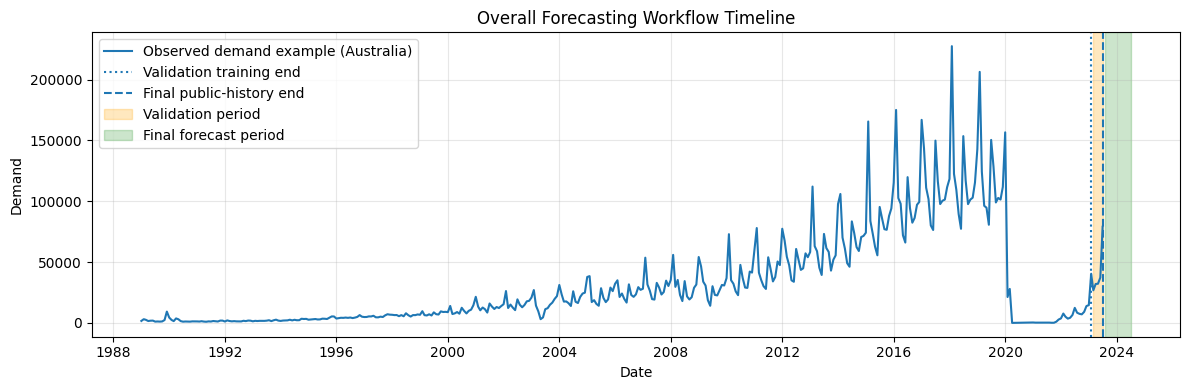

In [138]:
# Visualizing the overall modelling and forecasting windows
timeline_data = public_history_wide_to_2023M07[["Date", "Australia"]].copy()
timeline_data["_month_date"] = (
    timeline_data["Date"].map(month_label_to_period).dt.to_timestamp()
)

plt.figure(figsize=(12, 4))
plt.plot(
    timeline_data["_month_date"],
    timeline_data["Australia"],
    label="Observed demand example (Australia)"
)

# Marking the key cutoffs
plt.axvline(
    month_label_to_period("2023M02").to_timestamp(),
    linestyle=":",
    linewidth=1.5,
    label="Validation training end"
)

plt.axvline(
    month_label_to_period("2023M07").to_timestamp(),
    linestyle="--",
    linewidth=1.5,
    label="Final public-history end"
)

# Highlighting the validation period
plt.axvspan(
    month_label_to_period("2023M03").to_timestamp(),
    month_label_to_period("2023M07").to_timestamp(),
    alpha=0.25,
    color="orange",
    label="Validation period"
)

# Highlighting the final unseen forecast period
plt.axvspan(
    month_label_to_period("2023M08").to_timestamp(),
    month_label_to_period("2024M07").to_timestamp(),
    alpha=0.20,
    color="green",
    label="Final forecast period"
)

plt.title("Overall Forecasting Workflow Timeline")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

#### Step 11 - Summary & Findings

The final forecasting strategy uses a destination-specific hybrid approach based on validation MASE. Each destination was assigned the forecasting method that performed best during the common `2023M03` to `2023M07` validation period.

Using all allowable public demand history through `2023M07`, the selected models were rebuilt or regenerated and used to forecast the final `2023M08` to `2024M07` horizon. Their destination-specific forecasts were then combined into `forecast_submission_wide`.

The resulting table contains 12 forecast months and all 20 required destinations, with no missing, non-finite, or negative values. Q4 modelling and final forecast construction are therefore complete.

-------------------------

In [141]:
#BOOKMARK --------------------->

### Q5. Final forecast submission and assessment-period performance evaluation [30 marks]

Create `forecast_submission_wide`, a visible wide-format DataFrame with one `Date` column, exactly the 20 public-dataset destination columns, and exactly 12 rows for `2023M08` to `2024M07`.

Both the visible final forecast table and the submitted CSV are required. Before export, run `validate_forecast_actual_wide(...)` in forecast-only mode and store the fixed-key dictionary as `forecast_submission_audit`. It must contain every key in `Q2_AUDIT_FIELDS`, use `can_align=None`, and report `is_valid=True` before export.

Forecast values must be numeric, finite, destination-specific, and stable enough for assessment. Do not include assessment-period actual/result values. Avoid placeholder constants, copied actual/result values, uncontrolled rerun changes, and manual edits after export.

Export directly from `forecast_submission_wide`:

```python
forecast_submission_wide.to_csv(
    "SIG742-2026T2-A2-<GroupID>-Forecast.csv",
    index=False,
)
```

The teaching-team evaluator will read this CSV as a wide table and compare it with the assessment-period actual/result table after checking the schema.

**Required answer markers:** Do not delete, rename, edit, move, or reorder the Q5 START/END marker comments below. Write your response between them.

<!-- A2:ANSWER:Q5:START -->
Write your Q5 final forecast construction and export notes here. Delete this sentence before submission.
<!-- A2:ANSWER:Q5:END -->

In [74]:
forecast_submission_wide = None  # TODO: final wide-format all-20 destination forecast table.
forecast_submission_audit = None  # TODO: fixed-key Q2 forecast-only audit dictionary.

# Example once forecast_submission_wide is complete:
# forecast_submission_audit = validate_forecast_actual_wide(
#     forecast_submission_wide,
#     actual_wide_df=None,
#     required_months=FINAL_FORECAST_MONTHS,
#     required_destinations=REQUIRED_DESTINATIONS,
#     date_column=FINAL_FORECAST_DATE_COLUMN,
# )
# assert list(forecast_submission_audit) == Q2_AUDIT_FIELDS
# assert forecast_submission_audit["can_align"] is None
# assert forecast_submission_audit["is_valid"] is True

# Export the DataFrame directly. Replace <GroupID> before saving. Use index=False;
# an unnamed exported index is an extra column. Do not edit the CSV after export.
# forecast_submission_wide = forecast_submission_wide[FINAL_FORECAST_COLUMNS]
# forecast_submission_wide.to_csv(
#     "SIG742-2026T2-A2-<GroupID>-Forecast.csv",
#     index=False,
# )

### Q6. Performance-measure discussion and selected-market forecast analysis [20 marks]

Part A [10]: Use the [A2 Forecast Measures Guide](SIG742-2026T2-A2-Forecast-Measures-Guide.md), `baseline_validation_summary`, `validation_metrics`, and selected model evidence to discuss MASE and MAPE. Treat them as two required views, not alternatives. Cover MASE scale-free comparison, unstable/few-pair denominators, and MAPE zero/small-actual instability.

Part B [10]: Analyse Australia, Japan, and two additional destinations from the dataset. For each selected market, discuss historical demand pattern, baseline comparison, selected model validation behaviour, final forecast shape and plausibility, uncertainty and risks, and at least one supporting plot or table.

No separate `selected_market_analysis` object is required; complete this section in the written-answer cell and place supporting plots/tables near the discussion.

**Required answer markers:** Do not delete, rename, edit, move, or reorder the Q6 START/END marker comments below. Write your response between them.

<!-- A2:ANSWER:Q6:START -->
Write your Q6 performance-measure discussion and selected-market analysis here. Delete this sentence before submission.
<!-- A2:ANSWER:Q6:END -->


## Part III: Group video and collaboration presentation

### Question 7: Group video and collaboration explanation [15 marks]

Submit an 8-12 minute group video according to the Olympus Assignment requirements. Every group member should participate unless the unit chair has approved an alternative arrangement. The video must show code execution, identify the submitted forecast CSV, explain how the CSV can be regenerated from `forecast_submission_wide`, and let each member explain a meaningful part of the submitted work.

**Required answer markers:** Do not delete, rename, edit, move, or reorder the Q7 START/END marker comments below. Write your response between them.

<!-- A2:ANSWER:Q7:START -->
Record the submitted video filename or link, member participation summary, contribution summary, and any approved alternative arrangement here. Delete this sentence before submission.
<!-- A2:ANSWER:Q7:END -->


## Dataset and external source acknowledgement

Acknowledge the TULIP Lab `ISF-TDF2023` dataset and every external source used by your group. Include source URLs or citations, retrieval dates where relevant, and cutoff evidence.

Dataset acknowledgement to include or adapt:

```text
Dataset: ISF-TDF2023.
Publisher: TULIP Lab.
Repository: TULIP Lab Open Data Repository, https://github.com/tulip-lab/open-data.
Licence: CC BY 4.0 unless otherwise stated.
Suggested attribution: TULIP Lab. TULIP Lab Open Data Repository. https://github.com/tulip-lab/open-data. Licensed under CC BY 4.0. Also cite Zhang, Song, Li, Law, and Li (2026).
Associated publication: Zhang, Yishuo; Song, Baobao; Li, Xin; Law, Rob; Li, Gang (2026). Imputation recovery tourism demand forecasting. Annals of Tourism Research, 118, Article 104144. https://doi.org/10.1016/j.annals.2026.104144.
```


## Submission checklist

Before submitting, check that:

- `GROUP_INFO` is complete and required headings/functions/objects/answer markers are preserved.
- The [A2 Forecast Measures Guide](SIG742-2026T2-A2-Forecast-Measures-Guide.md) has been used for MASE/MAPE handling.
- `None` placeholders have been replaced with completed objects, displayed outputs, or concise evidence summaries.
- The notebook runs top to bottom in a clean runtime and can regenerate the final CSV.
- Random seeds or controlled stochastic behaviour are documented where relevant.
- The PDF includes relevant outputs, figures, tables, and explanations.
- Q1 returns a DataFrame with the required row and column order.
- Q2 returns a dictionary with every key in `Q2_AUDIT_FIELDS` and the required forecast-only `None` values.
- Q3 returns `(destination_metrics, aggregate_metrics)` using `DESTINATION_METRIC_COLUMNS` and `AGGREGATE_METRIC_FIELDS`.
- `baseline_validation_comparison` includes both baselines, all 20 destinations, required measure columns, denominator diagnostics, and row counts.
- `baseline_validation_summary` includes aggregate measures for both baselines.
- `validation_forecasts`, `validation_metrics`, and `model_summary` use their required minimum columns and cover the required models.
- `model_summary` contains exactly one `selected=True` row.
- `forecast_submission_wide` has one `Date` column, exactly 20 destination columns, and exactly 12 rows for `2023M08` to `2024M07`.
- `forecast_submission_audit` contains every Q2 audit key, uses `can_align=None`, and reports `is_valid=True` before export.
- The final forecast CSV is exported directly from `forecast_submission_wide` with `index=False` and no manual post-export edits.
- Forecast values are numeric, finite, destination-specific, and not placeholders or copied actual/result values.
- External data sources are cited, cutoff-safe, and included in `external_data/` where required and permitted.
- No credentials, private data, private paths, or restricted links are included.
- The group video and any contribution material follow Olympus instructions.